# Environment & GPU Verification

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# Device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Selected device :", device)

if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    print("CUDA version    :", torch.version.cuda)
    print("GPU count       :", torch.cuda.device_count())

PyTorch version : 2.7.1+cu128
CUDA available  : True
Selected device : cuda
GPU name        : NVIDIA GeForce GTX 1650
CUDA version    : 12.8
GPU count       : 1


# Define the Project

# 📈 Tesla Stock Price Forecasting Using LSTM

## Project Objective

Build a PyTorch-based Long Short-Term Memory (LSTM) time-series
forecasting system that learns temporal patterns from historical
Tesla stock-price data and predicts future stock prices.

## Primary Objective

Given a sequence of historical Tesla trading observations,
predict the stock price at a future time horizon.

### Input

Historical Tesla stock observations over the previous N trading days.

### Model

Long Short-Term Memory (LSTM) neural network implemented using PyTorch.

### Output

Predicted Tesla stock price for the next forecasting horizon.

## Project Goals

- Perform real-world financial time-series preprocessing
- Preserve chronological ordering
- Prevent temporal data leakage
- Construct sliding-window sequences
- Train an LSTM using GPU acceleration
- Compare against a naive forecasting baseline
- Evaluate using MAE, MSE and RMSE
- Perform error analysis
- Conduct controlled experiments
- Select and evaluate a final model
- Build a reproducible inference pipeline

# Mathematical Problem Formulation

## Mathematical Problem Formulation

Let the historical Tesla time series be:

    x₁, x₂, x₃, ..., xₜ

We construct a sequence of observations using a lookback window
of length N.

For a given time t:

    Xₜ = [xₜ₋ₙ₊₁, ..., xₜ₋₁, xₜ]

The LSTM receives this sequence and produces:

    ŷₜ₊₁ = fθ(Xₜ)

where:

- Xₜ = historical input sequence
- N = sequence length / lookback window
- fθ = LSTM model parameterized by θ
- ŷₜ₊₁ = predicted future price

The actual target is:

    yₜ₊₁

The model learns parameters θ by minimizing a regression loss
between the predicted and actual target values.

Conceptually:

    Historical Window
          ↓
    ┌─────────────────┐
    │ t-N ... t-2  t-1│
    └─────────────────┘
          ↓
        LSTM
          ↓
    Predicted Price
          ↓
       ŷ(t+1)

Target:

       y(t+1)

# Define the Initial Success Criteria

## Initial Success Criteria

The project will NOT consider the LSTM successful simply because
the training loss decreases.

The model must be evaluated against:

### 1. Naive Baseline

A simple forecasting strategy:

    ŷₜ₊₁ = yₜ

In other words:

    next price ≈ previous price

### 2. Regression Metrics

Primary metrics:

- MAE  → Mean Absolute Error
- MSE  → Mean Squared Error
- RMSE → Root Mean Squared Error

R² may be considered if it provides meaningful interpretation.

### 3. Chronological Generalization

The model must perform evaluation on data that occurs
chronologically after the training period.

### 4. Leakage-Free Pipeline

The following must not leak future information:

- Scaling
- Feature engineering
- Sequence construction
- Model validation
- Test-set processing

### 5. Error Analysis

We will inspect:

- Actual vs predicted values
- Prediction errors
- Training/validation loss
- Forecast behaviour
- Periods of large errors

### 6. Controlled Experiments

Important hyperparameters will be changed systematically,
one meaningful variable at a time.

### Final Question

The final project should answer:

"Does the LSTM provide useful forecasting performance on
unseen chronological Tesla data compared with a simple baseline?"

# Define the Dataset Contract

# 📊 Dataset Definition

## Asset

Tesla, Inc. (TSLA)

## Frequency

Daily trading data

## Initial Target

Closing price (`Close`)

## Initial Features

For the first experiment:

- Close

Later experiments may investigate:

- Open
- High
- Low
- Volume

## Prediction Task

Given the previous N trading days of Tesla closing prices:

    [Close(t-N+1), ..., Close(t)]

predict:

    Close(t+1)

## Important Constraint

Only information available at or before time t may be used
to predict the target at t+1.

Future observations must never enter the input sequence.

## Dataset Requirements

The dataset should contain:

- Trading date
- Open
- High
- Low
- Close
- Volume

The data must be chronologically ordered and inspected for:

- Missing values
- Duplicate dates
- Invalid timestamps
- Missing trading periods
- Unexpected values

In [2]:
import yfinance as yf 

ticker = 'TSLA'

df = yf.download(
    ticker,
    period='max',
    interval='1d',
    auto_adjust=False,
    progress=True
)

[*********************100%***********************]  1 of 1 completed


# Inspecting the Data

In [3]:
df.shape

(4093, 6)

In [4]:
df.columns

MultiIndex([('Adj Close', 'TSLA'),
            (    'Close', 'TSLA'),
            (     'High', 'TSLA'),
            (      'Low', 'TSLA'),
            (     'Open', 'TSLA'),
            (   'Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [5]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500


In [6]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2026-09-30,354.809998,354.809998,355.220001,345.880005,352.109985,39235800
2026-10-01,354.109985,354.109985,359.790009,353.799988,356.809998,31080800
2026-10-02,370.589996,370.589996,374.600006,359.410004,360.079987,55330100
2026-10-05,378.730011,378.730011,381.589996,364.910004,369.000000,42232700
2026-10-06,380.679993,380.679993,383.329987,378.519989,381.980011,27671400


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4093 entries, 2010-06-29 to 2026-10-06
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, TSLA)  4093 non-null   float64
 1   (Close, TSLA)      4093 non-null   float64
 2   (High, TSLA)       4093 non-null   float64
 3   (Low, TSLA)        4093 non-null   float64
 4   (Open, TSLA)       4093 non-null   float64
 5   (Volume, TSLA)     4093 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 223.8 KB


In [8]:
df.isna().sum()

Price      Ticker
Adj Close  TSLA      0
Close      TSLA      0
High       TSLA      0
Low        TSLA      0
Open       TSLA      0
Volume     TSLA      0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
print('=======DATE RANGE=======')
print('Start Date: ',df.index.min())
print('End Date:   ',df.index.max())

=======DATE RANGE=======
Start Date:  2010-06-29 00:00:00
End Date:    2026-10-06 00:00:00


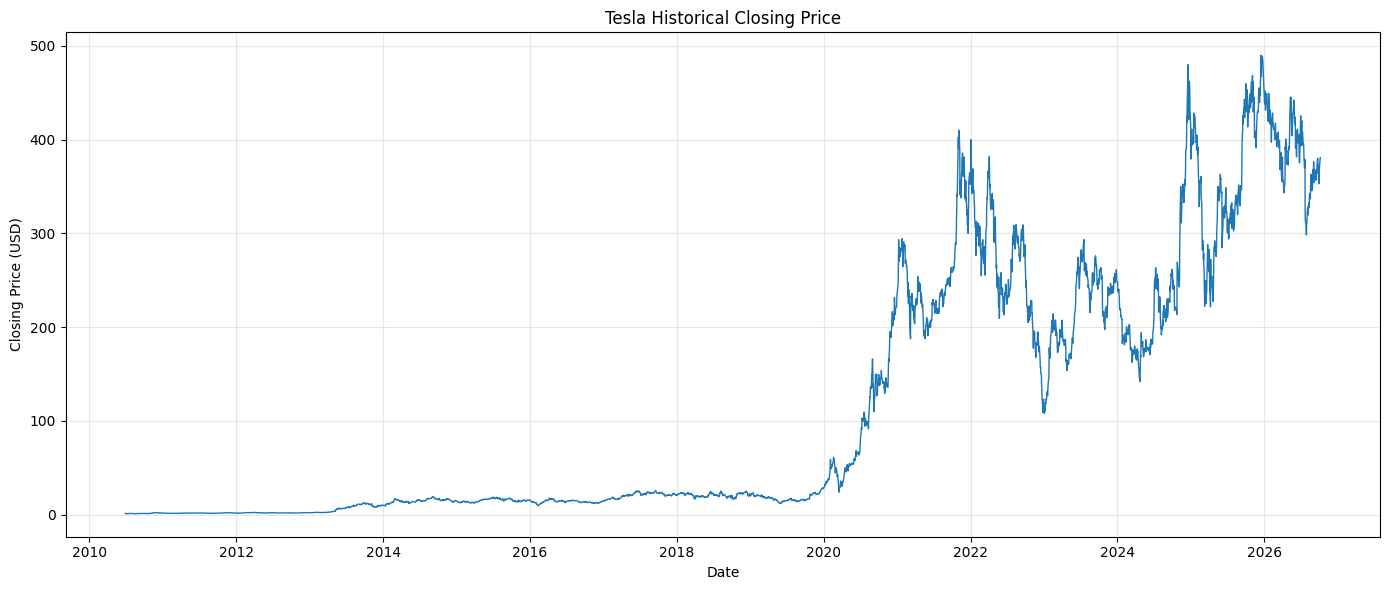

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Close'],
    linewidth = 1
)

plt.title("Tesla Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Flatten the MultiIndex 

In [12]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [13]:
print(df.columns)
display(df.head())

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500


# Standardize Column Order

In [14]:
df = df[
    [
        "Open",
        "High",
        "Low",
        "Close",
        "Adj Close",
        "Volume"
    ]
].copy()

print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4093 entries, 2010-06-29 to 2026-10-06
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       4093 non-null   float64
 1   High       4093 non-null   float64
 2   Low        4093 non-null   float64
 3   Close      4093 non-null   float64
 4   Adj Close  4093 non-null   float64
 5   Volume     4093 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 223.8 KB
None


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


In [15]:
# Basic price consistency checks

# checks wheter any price higher than High
print("High >= Low:", (df["High"] >= df["Low"]).all())
print("High >= Open:", (df["High"] >= df["Open"]).all())
print("High >= Close:", (df["High"] >= df["Close"]).all())

# checking any price which is lower than Low
print("\nLow <= Open:", (df["Low"] <= df["Open"]).all())
print("Low <= Close:", (df["Low"] <= df["Close"]).all())

# checks any negative prices and zero volumes
print("\nNegative prices:", (df[["Open", "High", "Low", "Close"]] < 0).any().any())
print("Zero volume:", (df["Volume"] == 0).sum())

High >= Low: True
High >= Open: True
High >= Close: True

Low <= Open: True
Low <= Close: True

Negative prices: False
Zero volume: 0


In [16]:
# daily percentage of returns 

df["Daily_Return"] = df["Close"].pct_change()

display(df["Daily_Return"].describe())

count    4092.000000
mean        0.001986
std         0.036080
min        -0.210628
25%        -0.016541
50%         0.001197
75%         0.019571
max         0.243951
Name: Daily_Return, dtype: float64


```
Mean daily return    ≈ +0.1985%
Std deviation        ≈ 3.61%
Worst observed day   ≈ -21.06%
Best observed day    ≈ +24.40%

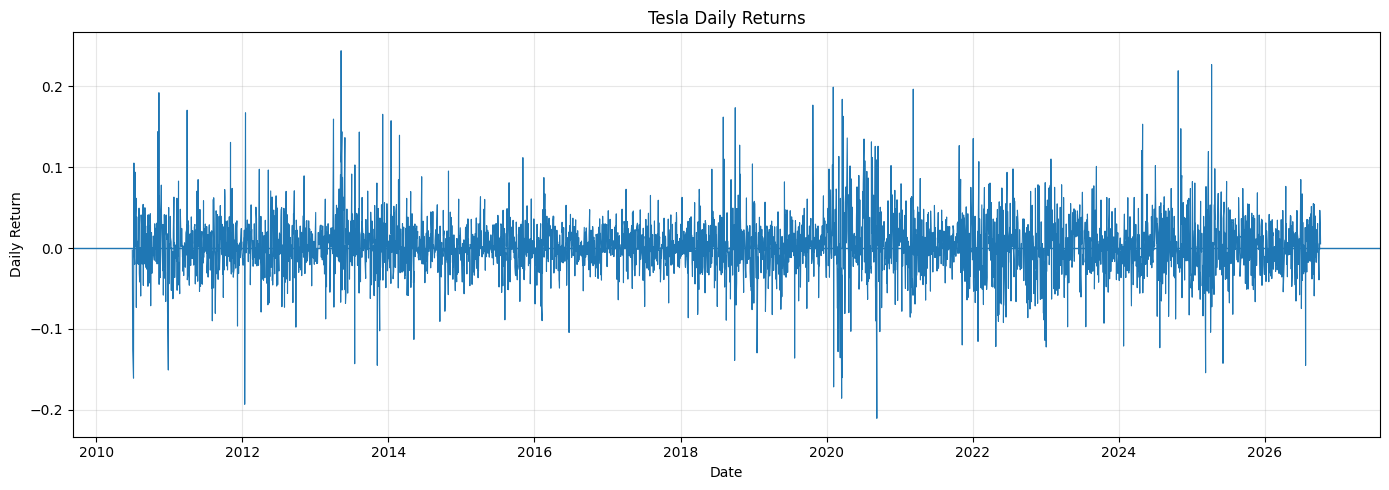

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["Daily_Return"],
    linewidth=0.8
)

plt.axhline(0, linewidth=1)

plt.title("Tesla Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Time-Series Characteristics

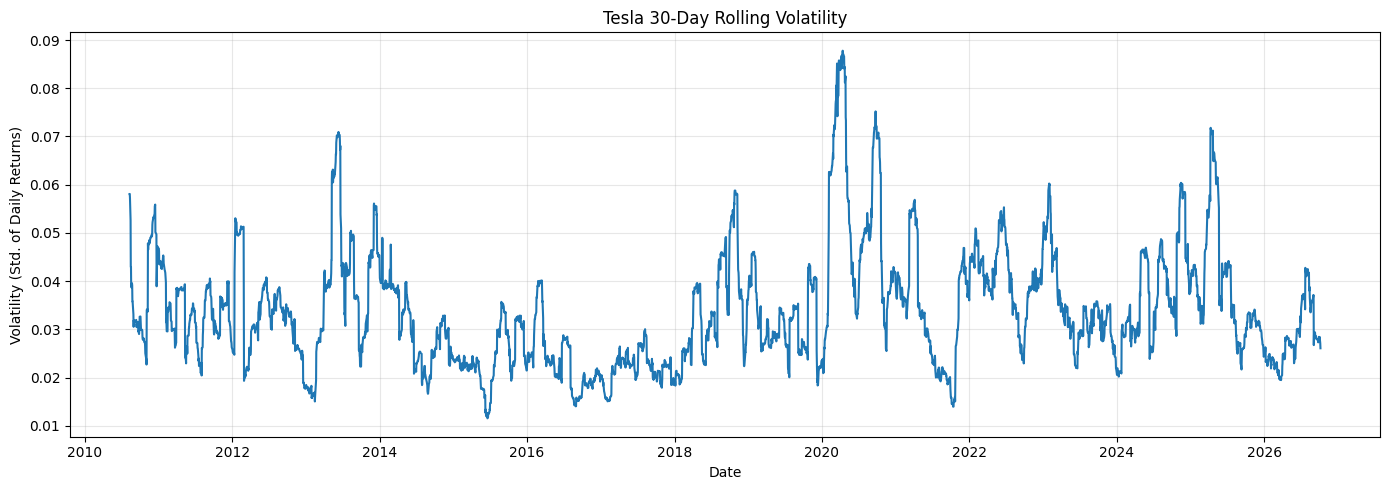

In [18]:
# 30-trading-day rolling volatility
df["Rolling_Volatility_30D"] = (
    df["Daily_Return"]
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["Rolling_Volatility_30D"]
)

plt.title("Tesla 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std. of Daily Returns)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

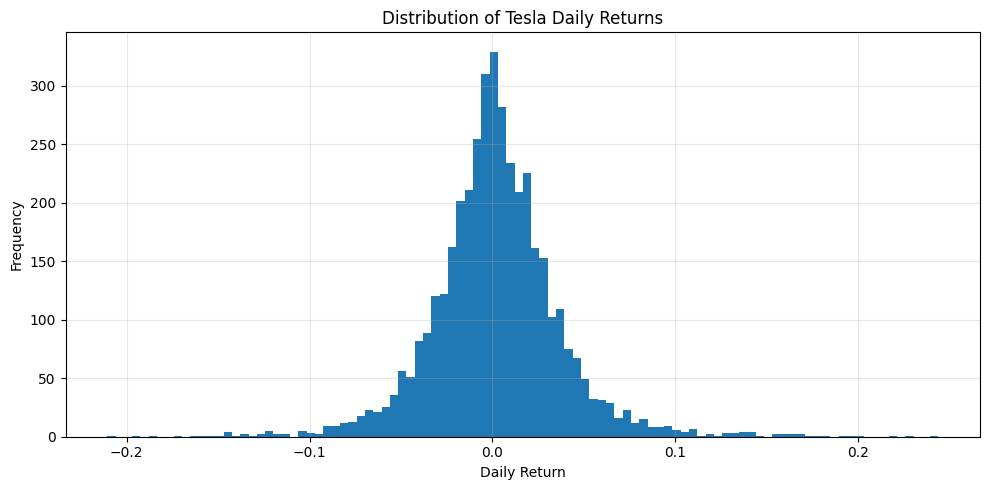

In [19]:
# Return Distribution 

plt.figure(figsize=(10, 5))

plt.hist(
    df["Daily_Return"].dropna(),
    bins=100
)

plt.title("Distribution of Tesla Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

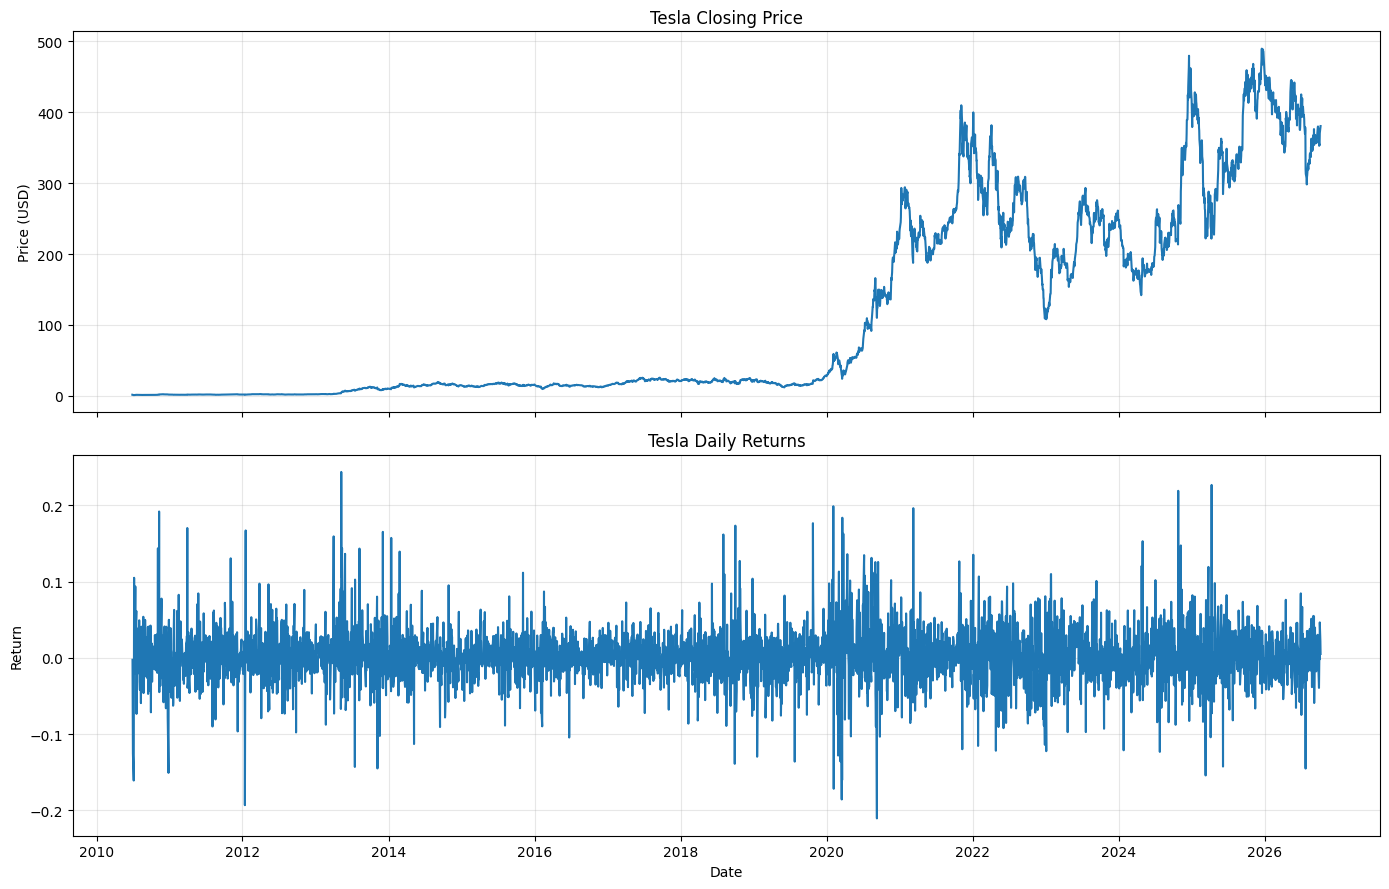

In [20]:
# Compare Price vs Returns

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(
    df.index,
    df["Close"]
)

axes[0].set_title("Tesla Closing Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    df.index,
    df["Daily_Return"]
)

axes[1].set_title("Tesla Daily Returns")
axes[1].set_ylabel("Return")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ADF Test — Stationarity

- **ADF (Augmented Dickey-Fuller) test** checks whether a time series is **stationary or non-stationary**.
- **Stationary:** statistical properties remain relatively stable over time.
- **Non-stationary:** statistical properties, especially the level/trend, change over time.

### Hypotheses

- **H₀:** Series is non-stationary (has a unit root).
- **H₁:** Series is stationary.

### p-value interpretation

| p-value | Conclusion |
|---|---|
| `< 0.05` | Reject H₀ → **Stationary** |
| `≥ 0.05` | Fail to reject H₀ → **Non-stationary** |

In [21]:
# Check Stationarity with ADF

from statsmodels.tsa.stattools import adfuller

price_result = adfuller(
    df["Close"].dropna()
)

return_result = adfuller(
    df["Daily_Return"].dropna()
)

print("===== ADF TEST: CLOSE PRICE =====")
print(f"ADF Statistic : {price_result[0]:.6f}")
print(f"p-value       : {price_result[1]:.6f}")

print("\n===== ADF TEST: DAILY RETURNS =====")
print(f"ADF Statistic : {return_result[0]:.6f}")
print(f"p-value       : {return_result[1]:.6f}")

===== ADF TEST: CLOSE PRICE =====
ADF Statistic : -1.012794
p-value       : 0.748570

===== ADF TEST: DAILY RETURNS =====
ADF Statistic : -64.240976
p-value       : 0.000000


C:\Users\yuvan\AppData\Local\Temp\ipykernel_4020\2777514825.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  price_result = adfuller(
C:\Users\yuvan\AppData\Local\Temp\ipykernel_4020\2777514825.py:9: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return_result = adfuller(


## Why Does Stationarity Matter?

A stationary time series has statistical properties that remain
relatively stable over time.

### Non-Stationary Series
- Mean/variance or other statistical properties can change over time.
- Historical patterns may not remain consistent in the future.
- Many traditional time-series methods work better with stationary data.
- A model may learn trends or changing regimes rather than stable temporal relationships.

### Stationary Series
- Statistical behaviour is more stable over time.
- Temporal relationships are generally easier to model consistently.
- This can improve the reliability of some time-series modelling approaches.

### Important for this Project

Tesla's raw Close price is non-stationary, while its daily returns
show strong evidence of stationarity according to the ADF test.

However, LSTMs can model non-stationary sequences, so non-stationarity
does NOT automatically mean we must transform the target.

We will use this analysis to make an informed decision about our
target representation and preprocessing.

# Choosing the Forecasting Target

In [22]:
# Compare Close vs Adj Close

close_adj_diff = (df['Close'] - df['Adj Close']).abs()

close_adj_diff = (df["Close"] - df["Adj Close"]).abs()

print("Maximum absolute difference:",
      close_adj_diff.max())

print("Number of rows with difference:",
      (close_adj_diff > 1e-10).sum())

print("\nClose statistics:")
print(df["Close"].describe())

print("\nAdjusted Close statistics:")
print(df["Adj Close"].describe())

Maximum absolute difference: 0.0
Number of rows with difference: 0

Close statistics:
count    4093.000000
mean      112.666880
std       136.921999
min         1.053333
25%        13.172000
50%        20.826000
75%       225.309998
max       489.880005
Name: Close, dtype: float64

Adjusted Close statistics:
count    4093.000000
mean      112.666880
std       136.921999
min         1.053333
25%        13.172000
50%        20.826000
75%       225.309998
max       489.880005
Name: Adj Close, dtype: float64


# 🎯 Target Definition

## Primary Target

We will forecast Tesla's next trading-day closing price.

    Target = Close(t+1)

Given:

    [Close(t-N+1), ..., Close(t)]

the model will learn:

    Close(t+1)

### Why Close?

- Directly matches the project's stock-price forecasting objective.
- Easy to interpret in USD.
- Provides a clear regression target.
- Allows straightforward comparison with a naive
  previous-price baseline.

### Alternative Formulation

Daily returns will be investigated later as a possible
alternative target formulation.

However, we will NOT switch to return prediction simply
because returns are more stationary.

The primary project remains:

    Historical Tesla Prices
            ↓
          LSTM
            ↓
    Next-Day Closing Price

## Why Not Use Returns as the Primary Target?

Returns are more stationary than raw prices, which can make them
attractive for time-series modelling.

However:

- Return prediction is a different problem from price prediction.
- A return forecast must be converted back into a price forecast.
- Small return errors can accumulate during multi-step forecasting.
- Our project objective is directly focused on forecasting Tesla's
  stock price.

Therefore, we keep Close as the primary target and treat return-based
forecasting as a potential controlled experiment.

In [23]:
# Create the Target Column

df["Target_Close"] = df["Close"].shift(-1)

display(
    df[["Close", "Target_Close"]].head(10)
)

Price,Close,Target_Close
Date,,
2010-06-29,1.592667,1.588667
2010-06-30,1.588667,1.464000
2010-07-01,1.464000,1.280000
2010-07-02,1.280000,1.074000
2010-07-06,1.074000,1.053333
2010-07-07,1.053333,1.164000
2010-07-08,1.164000,1.160000
2010-07-09,1.160000,1.136667
2010-07-12,1.136667,1.209333


## Forecasting Horizon

Primary forecasting horizon:

    1 trading day ahead

Notation:

    Input:
    X(t) = historical observations up to day t

    Target:
    y(t+1) = closing price on the next trading day

Therefore:

    Prediction Horizon = 1 trading day

# Chronological Train / Validation / Test Split

In [24]:
# Remove the Final Row coz it has no next day Target 

model_df = df.dropna(subset=['Target_Close']).copy()

n = len(model_df)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print('Length of the train,validation & test Respectively')
print(f'{len(train_df)} {len(val_df)} {len(test_df)}')
print()

print('Date Ranges of Train,Validation,Test Respectively')
print(f'{train_df.index.min().date()} ---> {train_df.index.max().date()}')
print(f'{val_df.index.min().date()} ---> {val_df.index.max().date()}')
print(f'{test_df.index.min().date()} ---> {test_df.index.max().date()}')

Length of the train,validation & test Respectively
3273 409 410

Date Ranges of Train,Validation,Test Respectively
2010-06-29 ---> 2023-06-29
2023-06-30 ---> 2025-02-14
2025-02-18 ---> 2026-10-05


In [25]:
# Verify Chronological Ordering

print("===== CHRONOLOGICAL SPLIT CHECK =====")

print(
    "Train ends before validation starts:",
    train_df.index.max() < val_df.index.min()
)

print(
    "Validation ends before test starts:",
    val_df.index.max() < test_df.index.min()
)

print(
    "Train starts before validation:",
    train_df.index.min() < val_df.index.min()
)

print(
    "Validation starts before test:",
    val_df.index.min() < test_df.index.min()
)

===== CHRONOLOGICAL SPLIT CHECK =====
Train ends before validation starts: True
Validation ends before test starts: True
Train starts before validation: True
Validation starts before test: True


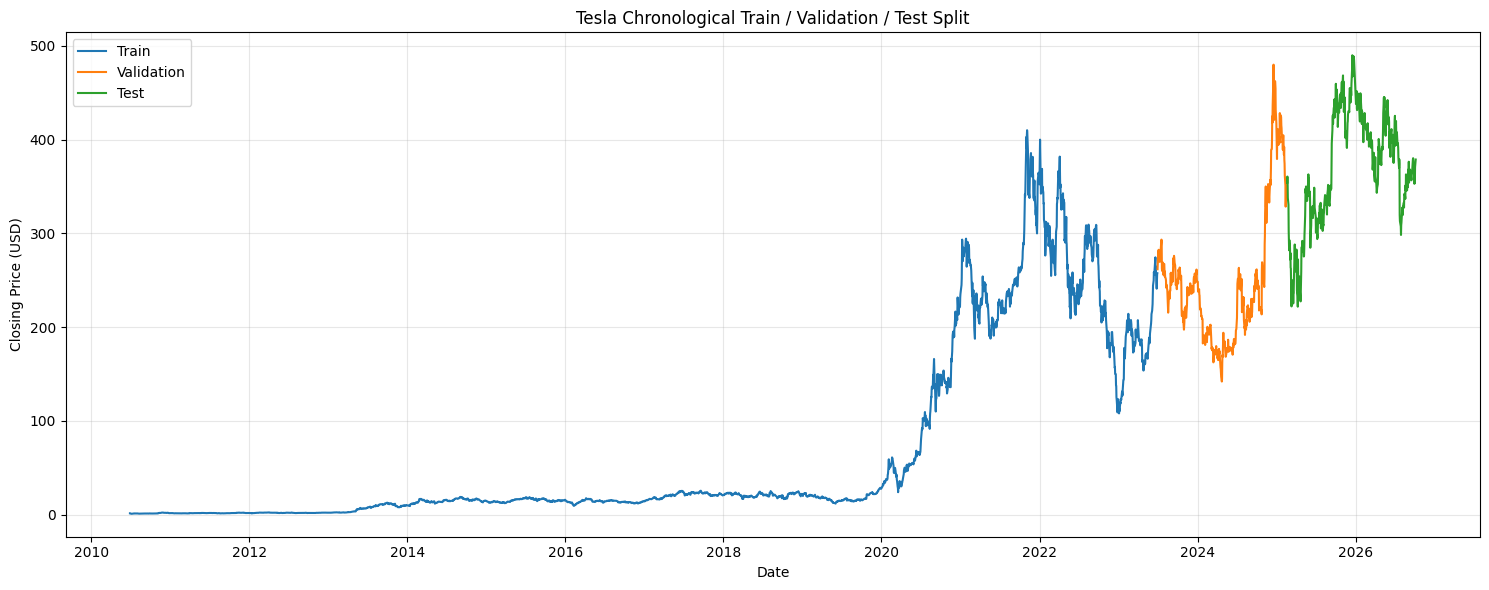

In [26]:
# Visualize the Split

plt.figure(figsize=(15, 6))

plt.plot(
    train_df.index,
    train_df["Close"],
    label="Train"
)

plt.plot(
    val_df.index,
    val_df["Close"],
    label="Validation"
)

plt.plot(
    test_df.index,
    test_df["Close"],
    label="Test"
)

plt.title("Tesla Chronological Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🧠 Why Do We Use Chronological Splitting?

Time-series observations are ordered in time.

Therefore:

    Past → Present → Future

Our model should learn from the past and be evaluated on later
observations.

### ❌ Random Split

A random train/test split can place:

    Future observations → Training
    Past observations   → Test

This allows information from the future to influence model
development and can produce overly optimistic results.

### ✅ Chronological Split

    TRAIN → VALIDATION → TEST
      Past       ↓        Future

Training uses earlier observations.

Validation is used for model selection and experimentation.

Test data represents later, unseen observations and is used
for the final evaluation.

### Key Principle

Never allow future information to influence the training
or model-selection process.

This is called preventing temporal data leakage.

# Scaling

## Why Do We Scale Time-Series Data?

Stock prices can span a very large numerical range.

Scaling puts the input values into a more suitable numerical
range for neural-network optimization.

Benefits include:

- More stable gradient-based optimization
- Better numerical conditioning
- Easier model training
- Preventing large-valued features from dominating optimization

### Important

Scaling does NOT make a non-stationary series stationary.

It only changes the numerical scale of the data.

For time-series data, the scaler must be fitted using training
data only to prevent future information from leaking into the model.

## Data Leakage in Scaling

- **Data leakage** occurs when information from the **validation/test set** influences the training process.
- The scaler must be **fitted only on the training set**.
- `fit()` learns parameters such as **mean and standard deviation** from the data.
- If we fit on the entire dataset, the scaler learns information from **future validation/test data**, causing leakage.
- Validation and test data should remain **unseen** during training.

### Correct approach

```python
scaler.fit(train_df[features])

train_scaled = scaler.transform(train_df[features])
val_scaled   = scaler.transform(val_df[features])
test_scaled  = scaler.transform(test_df[features])
```

### Rule 🧠

> **FIT → Training data only**  
> **TRANSFORM → Training + Validation + Test**

**Goal:** Ensure the model is evaluated fairly on truly unseen future data. 🔒📈

In [27]:
# Fit the Scaler ONLY on Training Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY using training closing prices
scaler.fit(train_df[["Close"]])

print("Training mean :", scaler.mean_[0])
print("Training std  :", scaler.scale_[0])

Training mean : 63.60988123628877
Training std  : 97.0461327126343


In [28]:
# Transform Train / Validation / Test

train_df["Close_scaled"] = scaler.transform(
    train_df[["Close"]]
)

val_df["Close_scaled"] = scaler.transform(
    val_df[["Close"]]
)

test_df["Close_scaled"] = scaler.transform(
    test_df[["Close"]]
)

print("Train:")
display(train_df[["Close", "Close_scaled"]].head())

print("\nValidation:")
display(val_df[["Close", "Close_scaled"]].head())

print("\nTest:")
display(test_df[["Close", "Close_scaled"]].head())

Train:


Price,Close,Close_scaled
Date,,
2010-06-29,1.592667,-0.639049
2010-06-30,1.588667,-0.639090
2010-07-01,1.464000,-0.640375
2010-07-02,1.280000,-0.642271
2010-07-06,1.074000,-0.644393



Validation:


Price,Close,Close_scaled
Date,,
2023-06-30,261.769989,2.041917
2023-07-03,279.820007,2.227911
2023-07-05,282.480011,2.255320
2023-07-06,276.540009,2.194112
2023-07-07,274.429993,2.172370



Test:


Price,Close,Close_scaled
Date,,
2025-02-18,354.109985,2.993423
2025-02-19,360.559998,3.059886
2025-02-20,354.399994,2.996411
2025-02-21,337.799988,2.825358
2025-02-24,330.529999,2.750446


In [29]:
# Verify the Scaling

print("\nTRAIN")
print(train_df["Close_scaled"].describe())

print("\nVALIDATION")
print(val_df["Close_scaled"].describe())

print("\nTEST")
print(test_df["Close_scaled"].describe())


TRAIN
count    3.273000e+03
mean    -1.042043e-16
std      1.000153e+00
min     -6.446063e-01
25%     -5.544773e-01
50%     -4.846068e-01
75%     -1.433258e-01
max      3.569025e+00
Name: Close_scaled, dtype: float64

VALIDATION
count    409.000000
mean       1.895444
std        0.725198
min        0.808277
25%        1.379551
50%        1.790902
75%        2.038516
max        4.289198
Name: Close_scaled, dtype: float64

TEST
count    410.000000
mean       3.147598
std        0.629069
min        1.630669
25%        2.718090
50%        3.196986
75%        3.665809
max        4.392448
Name: Close_scaled, dtype: float64


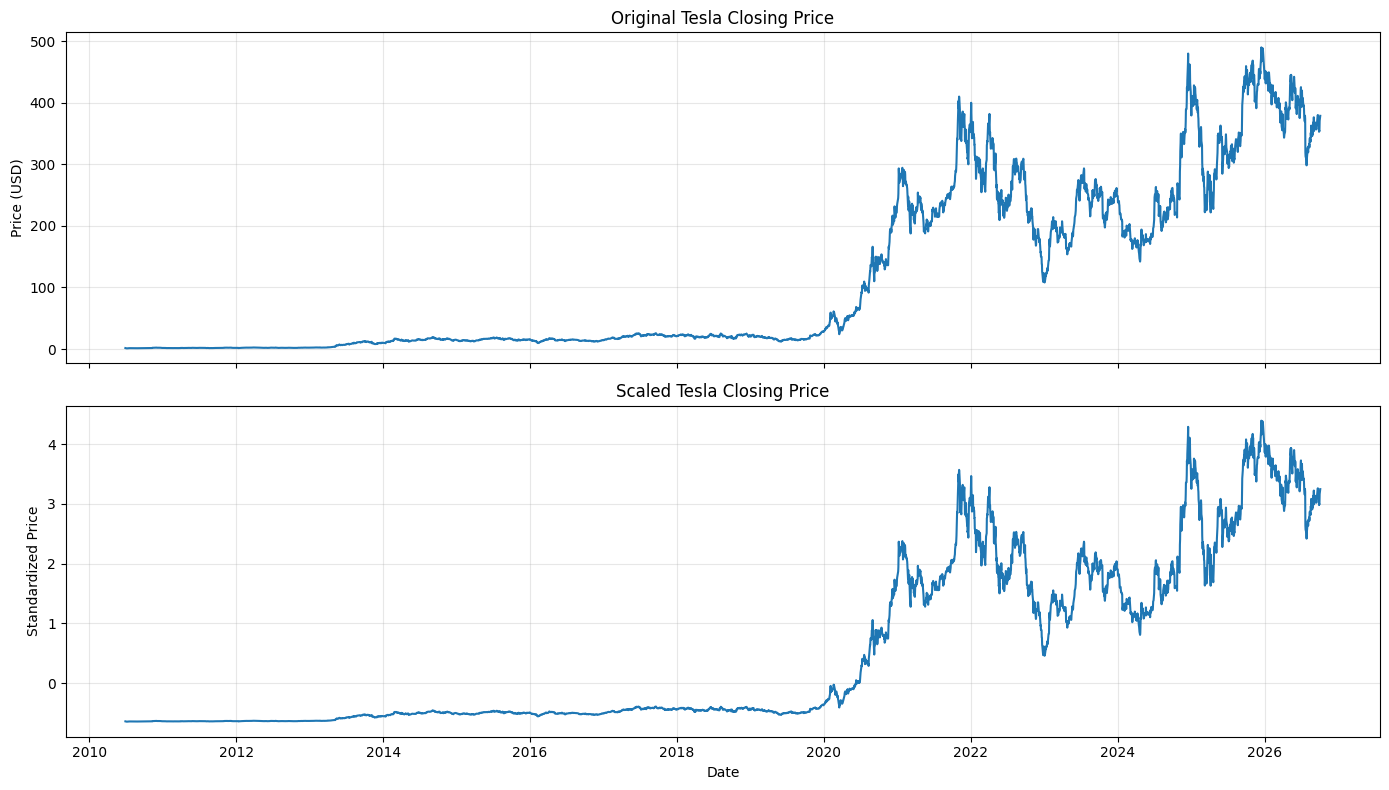

In [30]:
# Visualize Original vs Scaled Price

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    model_df.index,
    model_df["Close"]
)

axes[0].set_title("Original Tesla Closing Price")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(True, alpha=0.3)

# Combine the scaled values for visualization
scaled_all = pd.concat([
    train_df[["Close_scaled"]],
    val_df[["Close_scaled"]],
    test_df[["Close_scaled"]]
])

axes[1].plot(
    scaled_all.index,
    scaled_all["Close_scaled"]
)

axes[1].set_title("Scaled Tesla Closing Price")
axes[1].set_ylabel("Standardized Price")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Important Observation After Scaling

The training set has approximately:

    mean = 0
    std  = 1

because StandardScaler was fitted on the training data.

Validation and test data do NOT have to have mean = 0 and std = 1.

They are transformed using the training scaler.

For this Tesla dataset:

    Train mean      ≈ 0
    Validation mean ≈ 1.89
    Test mean       ≈ 3.15

This reflects the substantial change in Tesla's price level over time.

### Key Lesson

A scaler should learn its parameters from the training data only.

    Fit → Training data
    Transform → Training
    Transform → Validation
    Transform → Test

Never fit the scaler separately on future data.

Scaling changes numerical magnitude; it does NOT make a
non-stationary time series stationary.

# Sliding-Window Construction

In [31]:
# Scale the Targets

# Scale the target using the SAME scaler fitted on training Close prices

for split_df in [train_df, val_df, test_df]:

    split_df["Target_scaled"] = scaler.transform(
        split_df[["Target_Close"]].set_axis(["Close"], axis=1)
    ).ravel()

print("Train target:")
display(train_df[["Close", "Target_Close",'Close_scaled',"Target_scaled"]].head())

print("\nValidation target:")
display(val_df[["Close", "Target_Close",'Close_scaled',"Target_scaled"]].head())

print("\nTest target:")
display(test_df[["Close", "Target_Close",'Close_scaled',"Target_scaled"]].head())

Train target:


Price,Close,Target_Close,Close_scaled,Target_scaled
Date,,,,
2010-06-29,1.592667,1.588667,-0.639049,-0.639090
2010-06-30,1.588667,1.464000,-0.639090,-0.640375
2010-07-01,1.464000,1.280000,-0.640375,-0.642271
2010-07-02,1.280000,1.074000,-0.642271,-0.644393
2010-07-06,1.074000,1.053333,-0.644393,-0.644606



Validation target:


Price,Close,Target_Close,Close_scaled,Target_scaled
Date,,,,
2023-06-30,261.769989,279.820007,2.041917,2.227911
2023-07-03,279.820007,282.480011,2.227911,2.255320
2023-07-05,282.480011,276.540009,2.255320,2.194112
2023-07-06,276.540009,274.429993,2.194112,2.172370
2023-07-07,274.429993,269.609985,2.172370,2.122703



Test target:


Price,Close,Target_Close,Close_scaled,Target_scaled
Date,,,,
2025-02-18,354.109985,360.559998,2.993423,3.059886
2025-02-19,360.559998,354.399994,3.059886,2.996411
2025-02-20,354.399994,337.799988,2.996411,2.825358
2025-02-21,337.799988,330.529999,2.825358,2.750446
2025-02-24,330.529999,302.799988,2.750446,2.464705


In [32]:
# Define Our Initial Lookback
SEQUENCE_LENGTH = 60

print("Sequence length:", SEQUENCE_LENGTH)
print("Approximate trading history:",
      SEQUENCE_LENGTH / 5,
      "trading weeks")

Sequence length: 60
Approximate trading history: 12.0 trading weeks


In [33]:
def create_sequences(features, targets, sequence_length):

    X = []  # Input sequences
    y = []  # Target values

    # Start after we have enough historical data
    for i in range(sequence_length, len(features)):

        # Previous `sequence_length` days → LSTM input
        X.append(features[i - sequence_length:i])

        # Current day's target → prediction target
        y.append(targets[i])

    # Convert lists to NumPy arrays
    return np.array(X), np.array(y)

In [34]:
# Create TRAIN Sequences

train_features = train_df[["Close_scaled"]].values
train_targets = train_df["Target_scaled"].values

X_train, y_train = create_sequences(
    train_features,
    train_targets,
    SEQUENCE_LENGTH
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nNumber of training sequences:", len(X_train))
print("Sequence length:", X_train.shape[1])
print("Number of features:", X_train.shape[2])

X_train shape: (3213, 60, 1)
y_train shape: (3213,)

Number of training sequences: 3213
Sequence length: 60
Number of features: 1


## Sliding-Window Construction

A sequence length of 60 means the model receives the previous
60 trading days to predict the next trading day's closing price.

Example:

    X = [Day 1 ... Day 60]
    y = Day 61

The window then moves forward:

    X = [Day 2 ... Day 61]
    y = Day 62

### Boundary Handling

For validation and test sets, historical observations immediately
before the split can be used as input context.

Example:

    Last 60 training days
             ↓
    First validation prediction

This is not temporal leakage because those observations occurred
before the validation target.

However, future validation/test targets must never be included
in earlier input sequences.

# Validation & Test Sliding Windows

In [35]:
# we need last 60 days of training data for predicting the first validation data
# Use the final 60 training observations as historical context

# Historical context from the end of training
val_feature_context = train_df[["Close_scaled"]].tail(SEQUENCE_LENGTH)
val_target_context = train_df["Target_scaled"].tail(SEQUENCE_LENGTH)

# Add validation data
val_features = pd.concat([
    val_feature_context,
    val_df[["Close_scaled"]]
])

val_targets = pd.concat([
    val_target_context,
    val_df["Target_scaled"]
])

# Convert to NumPy
val_features = val_features.values
val_targets = val_targets.values

X_val, y_val = create_sequences(
    val_features,
    val_targets,
    SEQUENCE_LENGTH
)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (409, 60, 1)
y_val shape: (409,)


In [36]:
# Test Sequence Construction

# Historical context from the end of validation
test_feature_context = val_df[["Close_scaled"]].tail(SEQUENCE_LENGTH)
test_target_context = val_df["Target_scaled"].tail(SEQUENCE_LENGTH)

# Add test data
test_features = pd.concat([
    test_feature_context,
    test_df[["Close_scaled"]]
])

test_targets = pd.concat([
    test_target_context,
    test_df["Target_scaled"]
])

# Convert to NumPy
test_features = test_features.values
test_targets = test_targets.values

X_test, y_test = create_sequences(
    test_features,
    test_targets,
    SEQUENCE_LENGTH
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (410, 60, 1)
y_test shape: (410,)


In [37]:
print("===== FINAL SEQUENCE SHAPES =====")

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

===== FINAL SEQUENCE SHAPES =====
X_train : (3213, 60, 1)
y_train : (3213,)
X_val   : (409, 60, 1)
y_val   : (409,)
X_test  : (410, 60, 1)
y_test  : (410,)


# PyTorch Dataset + DataLoader

## Why PyTorch Dataset and DataLoader?

Dataset defines how the prepared samples are represented.

DataLoader provides the samples to the model in batches during
training.

Benefits:

- Efficient batch processing
- Cleaner training loop
- Supports shuffling of training samples
- Keeps validation/test evaluation organized

For time-series data:

- The chronological order of the original observations is preserved.
- We do NOT randomly shuffle the complete time series before splitting.
- Training batches may be shuffled after the chronological sequences
  have already been created, because each sequence is an independent
  supervised training sample at that stage.

Validation and test loaders should not be shuffled.

In [38]:
# Convert NumPy → PyTorch Tensors
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert inputs and targets to Float32 tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train:", y_train_tensor.shape, y_train_tensor.dtype)

print("X_val  :", X_val_tensor.shape, X_val_tensor.dtype)
print("y_val  :", y_val_tensor.shape, y_val_tensor.dtype)

print("X_test :", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test :", y_test_tensor.shape, y_test_tensor.dtype)

X_train: torch.Size([3213, 60, 1]) torch.float32
y_train: torch.Size([3213]) torch.float32
X_val  : torch.Size([409, 60, 1]) torch.float32
y_val  : torch.Size([409]) torch.float32
X_test : torch.Size([410, 60, 1]) torch.float32
y_test : torch.Size([410]) torch.float32


In [39]:
# Create PyTorch Datasets

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training samples  :", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples      :", len(test_dataset))

Training samples  : 3213
Validation samples: 409
Test samples      : 410


In [40]:
# Create DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Number of training batches  :", len(train_loader))
print("Number of validation batches:", len(val_loader))
print("Number of test batches      :", len(test_loader))

Number of training batches  : 51
Number of validation batches: 7
Number of test batches      : 7


In [41]:
X_batch, y_batch = next(iter(train_loader))

print("===== BATCH INFORMATION =====")

print("X batch shape :", X_batch.shape)
print("y batch shape :", y_batch.shape)

print("X dtype       :", X_batch.dtype)
print("y dtype       :", y_batch.dtype)

print("X device      :", X_batch.device)
print("y device      :", y_batch.device)


===== BATCH INFORMATION =====
X batch shape : torch.Size([64, 60, 1])
y batch shape : torch.Size([64])
X dtype       : torch.float32
y dtype       : torch.float32
X device      : cpu
y device      : cpu


In [42]:
# Inverse-scaling helper

import numpy as np

def inverse_scale(values):
    """
    Convert scaled values back to original Tesla Close prices (USD).
    """
    values = np.asarray(values).reshape(-1, 1)
    return scaler.inverse_transform(values).ravel()

In [43]:
# Naive baseline
# Our baseline assumption:
# Tomorrow's Close ≈ Today's Close

# Naive prediction: next day's price = current day's price
baseline_val_pred_scaled = X_val[:, -1, 0]
baseline_test_pred_scaled = X_test[:, -1, 0]

# Actual next-day prices
baseline_val_actual = y_val
baseline_test_actual = y_test

# Convert back to USD
baseline_val_pred = inverse_scale(baseline_val_pred_scaled)
baseline_val_actual_usd = inverse_scale(baseline_val_actual)

baseline_test_pred = inverse_scale(baseline_test_pred_scaled)
baseline_test_actual_usd = inverse_scale(baseline_test_actual)

print("Validation baseline predictions:", baseline_val_pred.shape)
print("Validation actual:", baseline_val_actual_usd.shape)
print("Test baseline predictions:", baseline_test_pred.shape)
print("Test actual:", baseline_test_actual_usd.shape)

Validation baseline predictions: (409,)
Validation actual: (409,)
Test baseline predictions: (410,)
Test actual: (410,)


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return mae, mse, rmse


val_mae, val_mse, val_rmse = calculate_metrics(
    baseline_val_actual_usd,
    baseline_val_pred
)

test_mae, test_mse, test_rmse = calculate_metrics(
    baseline_test_actual_usd,
    baseline_test_pred
)

print("NAIVE BASELINE")
print("-" * 40)

print(f"Validation MAE  : ${val_mae:.2f}")
print(f"Validation MSE  : {val_mse:.2f}")
print(f"Validation RMSE : ${val_rmse:.2f}")

print()

print(f"Test MAE        : ${test_mae:.2f}")
print(f"Test MSE        : {test_mse:.2f}")
print(f"Test RMSE       : ${test_rmse:.2f}")

NAIVE BASELINE
----------------------------------------
Validation MAE  : $9.70
Validation MSE  : 186.46
Validation RMSE : $13.66

Test MAE        : $12.61
Test MSE        : 272.45
Test RMSE       : $16.51


In [45]:
import torch
import torch.nn as nn


class TeslaLSTM(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        # LSTM output for every timestep
        lstm_output, _ = self.lstm(x)

        # Use the final timestep representation
        last_output = lstm_output[:, -1, :]

        # Predict next day's scaled Close
        output = self.fc(last_output)

        return output.squeeze(-1)


model = TeslaLSTM().to(device)

print(model)
print("\nModel device:", next(model.parameters()).device)

TeslaLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Model device: cuda:0


In [47]:
# Loss function + optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print("Loss function :", criterion)
print("Optimizer     :", optimizer)
print("Learning rate :", optimizer.param_groups[0]["lr"])

Loss function : MSELoss()
Optimizer     : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate : 0.001


In [48]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        # Move batch to GPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(X_batch)

        # Calculate loss
        loss = criterion(predictions, y_batch)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate loss
        total_loss += loss.item() * X_batch.size(0)

    epoch_loss = total_loss / len(loader.dataset)

    return epoch_loss

In [49]:
def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    epoch_loss = total_loss / len(loader.dataset)

    return epoch_loss

In [50]:
EPOCHS = 5

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/5] Train Loss: 0.375007 | Val Loss: 0.217850
Epoch [2/5] Train Loss: 0.026676 | Val Loss: 0.089360
Epoch [3/5] Train Loss: 0.014681 | Val Loss: 0.059781
Epoch [4/5] Train Loss: 0.014237 | Val Loss: 0.053754
Epoch [5/5] Train Loss: 0.012697 | Val Loss: 0.043846


In [51]:
EPOCHS = 50

history = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Save the best model state
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [01/50] Train Loss: 0.010777 | Val Loss: 0.040431
Epoch [02/50] Train Loss: 0.009578 | Val Loss: 0.043386
Epoch [03/50] Train Loss: 0.008787 | Val Loss: 0.036122
Epoch [04/50] Train Loss: 0.008600 | Val Loss: 0.036393
Epoch [05/50] Train Loss: 0.009121 | Val Loss: 0.036524
Epoch [06/50] Train Loss: 0.009118 | Val Loss: 0.035450
Epoch [07/50] Train Loss: 0.008444 | Val Loss: 0.038035
Epoch [08/50] Train Loss: 0.008041 | Val Loss: 0.035286
Epoch [09/50] Train Loss: 0.007736 | Val Loss: 0.033530
Epoch [10/50] Train Loss: 0.008889 | Val Loss: 0.035149
Epoch [11/50] Train Loss: 0.007458 | Val Loss: 0.031350
Epoch [12/50] Train Loss: 0.008033 | Val Loss: 0.039334
Epoch [13/50] Train Loss: 0.007412 | Val Loss: 0.031728
Epoch [14/50] Train Loss: 0.007530 | Val Loss: 0.047836
Epoch [15/50] Train Loss: 0.007462 | Val Loss: 0.038090
Epoch [16/50] Train Loss: 0.007471 | Val Loss: 0.039415
Epoch [17/50] Train Loss: 0.007266 | Val Loss: 0.031641
Epoch [18/50] Train Loss: 0.006984 | Val Loss: 0

In [52]:
model.load_state_dict(best_model_state)

print(f"Best validation loss: {best_val_loss:.6f}")

Best validation loss: 0.023194


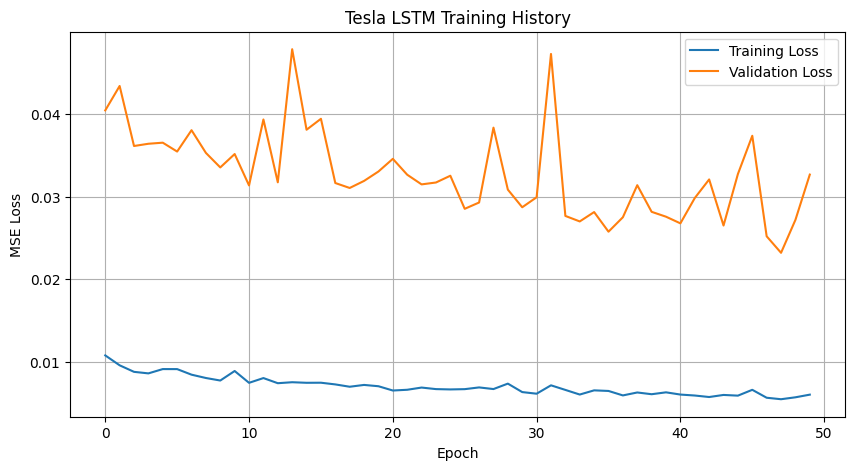

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Tesla LSTM Training History")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
# Make sure we are using the best validation checkpoint
model.load_state_dict(best_model_state)

model.eval()

val_predictions_scaled = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        val_predictions_scaled.append(
            predictions.cpu().numpy()
        )

val_predictions_scaled = np.concatenate(val_predictions_scaled)

print("Predictions shape:", val_predictions_scaled.shape)
print("Actual shape     :", y_val.shape)

Predictions shape: (409,)
Actual shape     : (409,)


In [55]:
val_predictions = inverse_scale(val_predictions_scaled)
val_actual = inverse_scale(y_val)

print("First 10 predictions:")
print(val_predictions[:10])

print("\nFirst 10 actual values:")
print(val_actual[:10])

First 10 predictions:
[258.3103  262.89883 275.8967  284.97797 284.78214 281.74213 276.80188
 274.28522 274.76166 279.00354]

First 10 actual values:
[279.82000732 282.48001099 276.54000854 274.42999268 269.60998535
 269.79000854 271.98999023 277.8999939  281.38000488 290.38000488]


In [56]:
lstm_val_mae, lstm_val_mse, lstm_val_rmse = calculate_metrics(
    val_actual,
    val_predictions
)

print("LSTM VALIDATION PERFORMANCE")
print("-" * 40)

print(f"MAE  : ${lstm_val_mae:.2f}")
print(f"MSE  : {lstm_val_mse:.2f}")
print(f"RMSE : ${lstm_val_rmse:.2f}")

LSTM VALIDATION PERFORMANCE
----------------------------------------
MAE  : $10.56
MSE  : 218.44
RMSE : $14.78


In [57]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "LSTM"
    ],
    "MAE": [
        val_mae,
        lstm_val_mae
    ],
    "MSE": [
        val_mse,
        lstm_val_mse
    ],
    "RMSE": [
        val_rmse,
        lstm_val_rmse
    ]
})

print(comparison.to_string(index=False))

         Model       MAE        MSE      RMSE
Naive Baseline  9.703178 186.461357 13.655085
          LSTM 10.557244 218.441149 14.779755


# Error Analysis

In [59]:
val_results = pd.DataFrame({
    "Actual": val_actual,
    "LSTM_Predicted": val_predictions,
    "Naive_Predicted": baseline_val_pred
})

val_results["LSTM_Error"] = (
    val_results["Actual"] - val_results["LSTM_Predicted"]
)

val_results["Naive_Error"] = (
    val_results["Actual"] - val_results["Naive_Predicted"]
)

val_results["LSTM_Absolute_Error"] = (
    val_results["LSTM_Error"].abs()
)

val_results["Naive_Absolute_Error"] = (
    val_results["Naive_Error"].abs()
)

display(val_results.head(10))

,Actual,LSTM_Predicted,Naive_Predicted,LSTM_Error,Naive_Error,LSTM_Absolute_Error,Naive_Absolute_Error
0,279.820007,258.310303,257.500000,21.509705,22.320007,21.509705,22.320007
1,282.480011,262.898834,261.769989,19.581177,20.710022,19.581177,20.710022
2,276.540009,275.896698,279.820007,0.643311,-3.279999,0.643311,3.279999
3,274.429993,284.977966,282.480011,-10.547974,-8.050018,10.547974,8.050018
4,269.609985,284.782135,276.540009,-15.172150,-6.930023,15.172150,6.930023
5,269.790009,281.742126,274.429993,-11.952118,-4.639984,11.952118,4.639984
6,271.989990,276.801880,269.609985,-4.811890,2.380005,4.811890,2.380005
7,277.899994,274.285217,269.790009,3.614777,8.109985,3.614777,8.109985
8,281.380005,274.761658,271.989990,6.618347,9.390015,6.618347,9.390015
9,290.380005,279.003540,277.899994,11.376465,12.480011,11.376465,12.480011


In [61]:
print('LSTM error Statistics')
display(val_results['LSTM_Error'].describe())

print()

print('Absolute LSTM error Statistics')
display(val_results['LSTM_Absolute_Error'].describe())

LSTM error Statistics


count    409.000000
mean      -0.001885
std       14.797856
min      -38.391098
25%       -8.479095
50%       -1.762039
75%        5.916595
max       64.874023
Name: LSTM_Error, dtype: float64


Absolute LSTM error Statistics


count    409.000000
mean      10.557244
std       10.356059
min        0.001266
25%        3.702133
50%        7.388046
75%       13.959045
max       64.874023
Name: LSTM_Absolute_Error, dtype: float64

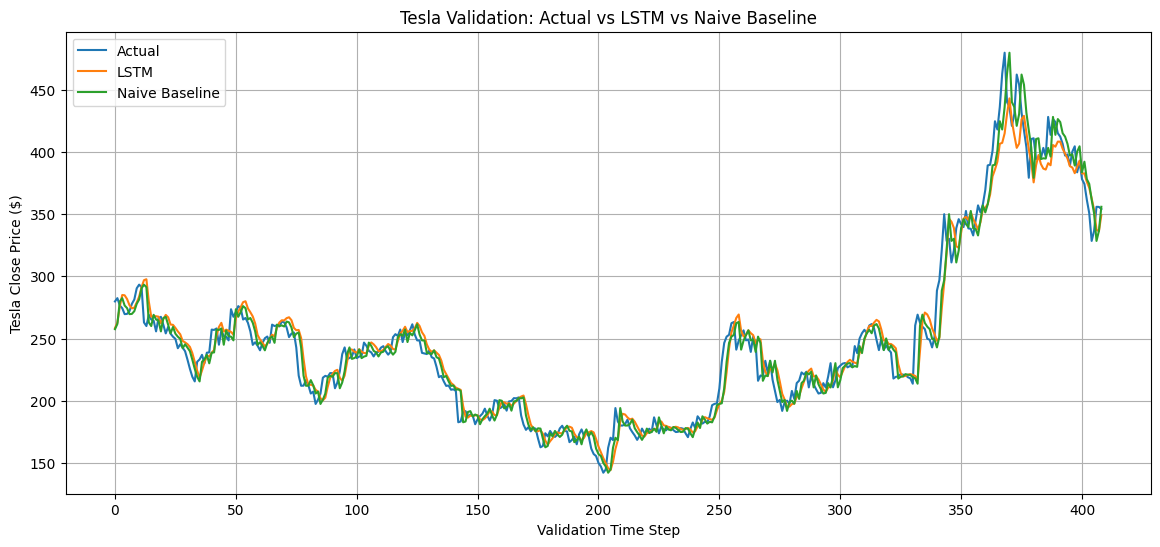

In [62]:
plt.figure(figsize=(14, 6))

plt.plot(
    val_results["Actual"].values,
    label="Actual"
)

plt.plot(
    val_results["LSTM_Predicted"].values,
    label="LSTM"
)

plt.plot(
    val_results["Naive_Predicted"].values,
    label="Naive Baseline"
)

plt.xlabel("Validation Time Step")
plt.ylabel("Tesla Close Price ($)")
plt.title("Tesla Validation: Actual vs LSTM vs Naive Baseline")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
largest_errors = (
    val_results
    .sort_values("LSTM_Absolute_Error", ascending=False)
    .head(10)
)

print(
    largest_errors[
        [
            "Actual",
            "LSTM_Predicted",
            "Naive_Predicted",
            "LSTM_Error",
            "LSTM_Absolute_Error"
        ]
    ].to_string(index=False)
)

    Actual  LSTM_Predicted  Naive_Predicted  LSTM_Error  LSTM_Absolute_Error
479.859985      414.985962       436.230011   64.874023            64.874023
462.279999      403.347443       421.059998   58.932556            58.932556
463.019989      407.387024       418.100006   55.632965            55.632965
350.000000      294.930817       296.910004   55.069183            55.069183
269.190002      217.045578       213.649994   52.144424            52.144424
454.130005      406.770416       430.600006   47.359589            47.359589
321.220001      274.233704       288.529999   46.986298            46.986298
296.910004      250.305557       251.440002   46.604446            46.604446
260.480011      219.849152       217.970001   40.630859            40.630859
288.529999      248.149490       242.839996   40.380508            40.380508


# Experiment 1 — 30-Day Sequence

In [64]:
EXPERIMENT_SEQUENCE_LENGTH = 30

# Training sequences
train_features = train_df[["Close_scaled"]].values
train_targets = train_df["Target_scaled"].values

X_train_30, y_train_30 = create_sequences(
    train_features,
    train_targets,
    EXPERIMENT_SEQUENCE_LENGTH
)

# Validation sequences
val_feature_context_30 = train_df[["Close_scaled"]].tail(
    EXPERIMENT_SEQUENCE_LENGTH
)

val_target_context_30 = train_df["Target_scaled"].tail(
    EXPERIMENT_SEQUENCE_LENGTH
)

val_features_30 = pd.concat([
    val_feature_context_30,
    val_df[["Close_scaled"]]
])

val_targets_30 = pd.concat([
    val_target_context_30,
    val_df["Target_scaled"]
])

X_val_30, y_val_30 = create_sequences(
    val_features_30.values,
    val_targets_30.values,
    EXPERIMENT_SEQUENCE_LENGTH
)


# Test sequences
# We'll construct them now,
# but won't use test for tuning.
test_feature_context_30 = val_df[["Close_scaled"]].tail(
    EXPERIMENT_SEQUENCE_LENGTH
)

test_target_context_30 = val_df["Target_scaled"].tail(
    EXPERIMENT_SEQUENCE_LENGTH
)

test_features_30 = pd.concat([
    test_feature_context_30,
    test_df[["Close_scaled"]]
])

test_targets_30 = pd.concat([
    test_target_context_30,
    test_df["Target_scaled"]
])

X_test_30, y_test_30 = create_sequences(
    test_features_30.values,
    test_targets_30.values,
    EXPERIMENT_SEQUENCE_LENGTH
)


print("30-Day Experiment")
print("-" * 40)
print("X_train:", X_train_30.shape)
print("y_train:", y_train_30.shape)
print("X_val  :", X_val_30.shape)
print("y_val  :", y_val_30.shape)
print("X_test :", X_test_30.shape)
print("y_test :", y_test_30.shape)

30-Day Experiment
----------------------------------------
X_train: (3243, 30, 1)
y_train: (3243,)
X_val  : (409, 30, 1)
y_val  : (409,)
X_test : (410, 30, 1)
y_test : (410,)


In [65]:
# Create experiment DataLoaders
# Convert NumPy arrays to tensors

X_train_30_tensor = torch.tensor(
    X_train_30,
    dtype=torch.float32
)

y_train_30_tensor = torch.tensor(
    y_train_30,
    dtype=torch.float32
)

X_val_30_tensor = torch.tensor(
    X_val_30,
    dtype=torch.float32
)

y_val_30_tensor = torch.tensor(
    y_val_30,
    dtype=torch.float32
)


# Datasets

train_dataset_30 = TensorDataset(
    X_train_30_tensor,
    y_train_30_tensor
)

val_dataset_30 = TensorDataset(
    X_val_30_tensor,
    y_val_30_tensor
)


# DataLoaders
train_loader_30 = DataLoader(
    train_dataset_30,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_30 = DataLoader(
    val_dataset_30,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader_30))
print("Val batches  :", len(val_loader_30))

Train batches: 51
Val batches  : 7


In [66]:
# Fresh model for Experiment #1

model_30 = TeslaLSTM(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

criterion_30 = nn.MSELoss()

optimizer_30 = torch.optim.Adam(
    model_30.parameters(),
    lr=1e-3
)

print(model_30)
print("\nDevice:", next(model_30.parameters()).device)

TeslaLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Device: cuda:0


In [67]:
# Train Experiment 1
EPOCHS_30 = 50

history_30 = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_30 = float("inf")
best_model_state_30 = None


for epoch in range(EPOCHS_30):

    train_loss = train_one_epoch(
        model_30,
        train_loader_30,
        criterion_30,
        optimizer_30,
        device
    )

    val_loss = validate_one_epoch(
        model_30,
        val_loader_30,
        criterion_30,
        device
    )

    history_30["train_loss"].append(train_loss)
    history_30["val_loss"].append(val_loss)

    if val_loss < best_val_loss_30:

        best_val_loss_30 = val_loss

        best_model_state_30 = {
            key: value.detach().cpu().clone()
            for key, value in model_30.state_dict().items()
        }

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS_30}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


print("\nBest validation loss:", best_val_loss_30)
print(
    "Best epoch:",
    np.argmin(history_30["val_loss"]) + 1
)

Epoch [01/50] Train Loss: 0.308741 | Val Loss: 0.270472
Epoch [02/50] Train Loss: 0.021520 | Val Loss: 0.087198
Epoch [03/50] Train Loss: 0.013161 | Val Loss: 0.058764
Epoch [04/50] Train Loss: 0.011346 | Val Loss: 0.051440
Epoch [05/50] Train Loss: 0.010280 | Val Loss: 0.044697
Epoch [06/50] Train Loss: 0.010222 | Val Loss: 0.056362
Epoch [07/50] Train Loss: 0.010490 | Val Loss: 0.054365
Epoch [08/50] Train Loss: 0.008528 | Val Loss: 0.039788
Epoch [09/50] Train Loss: 0.008552 | Val Loss: 0.036987
Epoch [10/50] Train Loss: 0.009145 | Val Loss: 0.039347
Epoch [11/50] Train Loss: 0.008485 | Val Loss: 0.036381
Epoch [12/50] Train Loss: 0.007577 | Val Loss: 0.035044
Epoch [13/50] Train Loss: 0.007576 | Val Loss: 0.033299
Epoch [14/50] Train Loss: 0.007144 | Val Loss: 0.037468
Epoch [15/50] Train Loss: 0.007186 | Val Loss: 0.032760
Epoch [16/50] Train Loss: 0.007486 | Val Loss: 0.035059
Epoch [17/50] Train Loss: 0.007508 | Val Loss: 0.033517
Epoch [18/50] Train Loss: 0.007260 | Val Loss: 0

In [68]:
 # Restore the best 30-day model

model_30.load_state_dict(best_model_state_30)
model_30.eval()

val_predictions_30_scaled = []

with torch.no_grad():

    for X_batch, _ in val_loader_30:

        X_batch = X_batch.to(device)

        predictions = model_30(X_batch)

        val_predictions_30_scaled.append(
            predictions.cpu().numpy()
        )

val_predictions_30_scaled = np.concatenate(
    val_predictions_30_scaled
)

val_predictions_30 = inverse_scale(
    val_predictions_30_scaled
)

val_actual_30 = inverse_scale(y_val_30)

print("Predictions:", val_predictions_30.shape)
print("Actual     :", val_actual_30.shape)

Predictions: (409,)
Actual     : (409,)


In [69]:
mae_30, mse_30, rmse_30 = calculate_metrics(
    val_actual_30,
    val_predictions_30
)

print("30-DAY LSTM VALIDATION PERFORMANCE")
print("-" * 45)

print(f"MAE  : ${mae_30:.2f}")
print(f"MSE  : {mse_30:.2f}")
print(f"RMSE : ${rmse_30:.2f}")

30-DAY LSTM VALIDATION PERFORMANCE
---------------------------------------------
MAE  : $10.69
MSE  : 229.08
RMSE : $15.14


In [71]:
experiment_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "LSTM - 60 Days",
        "LSTM - 30 Days"
    ],
    "Sequence_Length": [
        None,
        60,
        30
    ],
    "MAE": [
        val_mae,
        lstm_val_mae,
        mae_30
    ],
    "MSE": [
        val_mse,
        lstm_val_mse,
        mse_30
    ],
    "RMSE": [
        val_rmse,
        lstm_val_rmse,
        rmse_30
    ]
})

display(experiment_results)

,Model,Sequence_Length,MAE,MSE,RMSE
0,Naive Baseline,NaN,9.703178,186.461357,13.655085
1,LSTM - 60 Days,60.0,10.557244,218.441149,14.779755
2,LSTM - 30 Days,30.0,10.694543,229.082817,15.135482


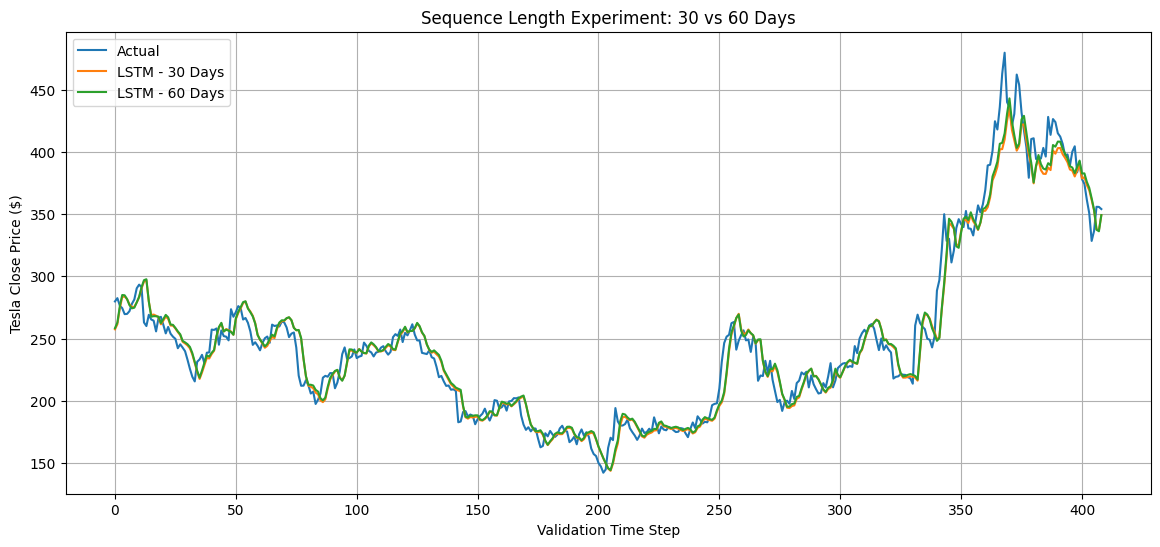

In [73]:
plt.figure(figsize=(14, 6))

plt.plot(
    val_actual_30,
    label="Actual"
)

plt.plot(
    val_predictions_30,
    label="LSTM - 30 Days"
)

plt.plot(
    val_predictions,
    label="LSTM - 60 Days"
)

plt.xlabel("Validation Time Step")
plt.ylabel("Tesla Close Price ($)")
plt.title("Sequence Length Experiment: 30 vs 60 Days")
plt.legend()
plt.grid(True)

plt.show()

# Experiment 2: Feature Expansion.

In [74]:
FEATURES = ["Open", "High", "Low", "Close", "Volume"]

feature_scaler = StandardScaler()

# Fit ONLY on training data
feature_scaler.fit(train_df[FEATURES])

train_multi = train_df.copy()
val_multi = val_df.copy()
test_multi = test_df.copy()

train_multi[FEATURES] = feature_scaler.transform(train_df[FEATURES])
val_multi[FEATURES] = feature_scaler.transform(val_df[FEATURES])
test_multi[FEATURES] = feature_scaler.transform(test_df[FEATURES])

print("Features:", FEATURES)
print("Input feature count:", len(FEATURES))

Features: ['Open', 'High', 'Low', 'Close', 'Volume']
Input feature count: 5


In [75]:
SEQUENCE_LENGTH = 60

# Train
X_train_multi, y_train_multi = create_sequences(
    train_multi[FEATURES].values,
    train_df["Target_scaled"].values,
    SEQUENCE_LENGTH
)

# Validation context
val_features_multi = pd.concat([
    train_multi[FEATURES].tail(SEQUENCE_LENGTH),
    val_multi[FEATURES]
])

val_targets_multi = pd.concat([
    train_df["Target_scaled"].tail(SEQUENCE_LENGTH),
    val_df["Target_scaled"]
])

X_val_multi, y_val_multi = create_sequences(
    val_features_multi.values,
    val_targets_multi.values,
    SEQUENCE_LENGTH
)

print("X_train:", X_train_multi.shape)
print("y_train:", y_train_multi.shape)
print("X_val  :", X_val_multi.shape)
print("y_val  :", y_val_multi.shape)

X_train: (3213, 60, 5)
y_train: (3213,)
X_val  : (409, 60, 5)
y_val  : (409,)


In [76]:
X_train_multi_tensor = torch.tensor(
    X_train_multi, dtype=torch.float32
)
y_train_multi_tensor = torch.tensor(
    y_train_multi, dtype=torch.float32
)

X_val_multi_tensor = torch.tensor(
    X_val_multi, dtype=torch.float32
)
y_val_multi_tensor = torch.tensor(
    y_val_multi, dtype=torch.float32
)

train_dataset_multi = TensorDataset(
    X_train_multi_tensor,
    y_train_multi_tensor
)

val_dataset_multi = TensorDataset(
    X_val_multi_tensor,
    y_val_multi_tensor
)

train_loader_multi = DataLoader(
    train_dataset_multi,
    batch_size=64,
    shuffle=True
)

val_loader_multi = DataLoader(
    val_dataset_multi,
    batch_size=64,
    shuffle=False
)

X_batch, y_batch = next(iter(train_loader_multi))

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 60, 5])
y batch: torch.Size([64])


In [77]:
model_multi = TeslaLSTM(
    input_size=5,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

criterion_multi = nn.MSELoss()

optimizer_multi = torch.optim.Adam(
    model_multi.parameters(),
    lr=1e-3
)

print(model_multi)
print("\nModel device:", next(model_multi.parameters()).device)

TeslaLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Model device: cuda:0


In [78]:
EPOCHS_MULTI = 50

history_multi = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_multi = float("inf")
best_model_state_multi = None

for epoch in range(EPOCHS_MULTI):

    train_loss = train_one_epoch(
        model_multi,
        train_loader_multi,
        criterion_multi,
        optimizer_multi,
        device
    )

    val_loss = validate_one_epoch(
        model_multi,
        val_loader_multi,
        criterion_multi,
        device
    )

    history_multi["train_loss"].append(train_loss)
    history_multi["val_loss"].append(val_loss)

    if val_loss < best_val_loss_multi:
        best_val_loss_multi = val_loss

        best_model_state_multi = {
            key: value.detach().cpu().clone()
            for key, value in model_multi.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_MULTI}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("\nBest validation loss:", best_val_loss_multi)

Epoch [01/50] Train Loss: 0.227849 | Val Loss: 0.242736
Epoch [02/50] Train Loss: 0.019948 | Val Loss: 0.086896
Epoch [03/50] Train Loss: 0.014681 | Val Loss: 0.051642
Epoch [04/50] Train Loss: 0.011249 | Val Loss: 0.040127
Epoch [05/50] Train Loss: 0.009132 | Val Loss: 0.036505
Epoch [06/50] Train Loss: 0.009587 | Val Loss: 0.038826
Epoch [07/50] Train Loss: 0.008786 | Val Loss: 0.036237
Epoch [08/50] Train Loss: 0.008389 | Val Loss: 0.041640
Epoch [09/50] Train Loss: 0.008620 | Val Loss: 0.041101
Epoch [10/50] Train Loss: 0.008524 | Val Loss: 0.037538
Epoch [11/50] Train Loss: 0.007674 | Val Loss: 0.042409
Epoch [12/50] Train Loss: 0.007911 | Val Loss: 0.032863
Epoch [13/50] Train Loss: 0.007836 | Val Loss: 0.041304
Epoch [14/50] Train Loss: 0.007514 | Val Loss: 0.034299
Epoch [15/50] Train Loss: 0.007649 | Val Loss: 0.032881
Epoch [16/50] Train Loss: 0.007237 | Val Loss: 0.038906
Epoch [17/50] Train Loss: 0.008487 | Val Loss: 0.069698
Epoch [18/50] Train Loss: 0.009117 | Val Loss: 0

In [79]:
model_multi.load_state_dict(best_model_state_multi)

print("Best multi-feature model restored.")
print("Best validation loss:", best_val_loss_multi)

Best multi-feature model restored.
Best validation loss: 0.02597094171459634


In [80]:
model_multi.eval()

val_predictions_multi = []

with torch.no_grad():

    for X_batch, _ in val_loader_multi:

        X_batch = X_batch.to(device)

        predictions = model_multi(X_batch)

        val_predictions_multi.extend(
            predictions.cpu().numpy()
        )

val_predictions_multi = np.array(val_predictions_multi)

# Convert scaled predictions back to dollars
val_predictions_multi = inverse_scale(
    val_predictions_multi
)

val_actual_multi = inverse_scale(
    y_val_multi
)

print("Predictions shape:", val_predictions_multi.shape)
print("Actual shape     :", val_actual_multi.shape)

print("\nFirst 10 predictions:")
print(val_predictions_multi[:10])

print("\nFirst 10 actual values:")
print(val_actual_multi[:10])

Predictions shape: (409,)
Actual shape     : (409,)

First 10 predictions:
[261.36288 265.13583 279.04364 285.21527 285.00845 285.744   282.39133
 279.66895 281.3293  282.84344]

First 10 actual values:
[279.82000732 282.48001099 276.54000854 274.42999268 269.60998535
 269.79000854 271.98999023 277.8999939  281.38000488 290.38000488]


In [81]:
mae_multi = mean_absolute_error(
    val_actual_multi,
    val_predictions_multi
)

mse_multi = mean_squared_error(
    val_actual_multi,
    val_predictions_multi
)

rmse_multi = np.sqrt(mse_multi)

print("Multi-Feature LSTM Results")
print("-" * 35)
print(f"MAE  : ${mae_multi:.4f}")
print(f"MSE  : {mse_multi:.4f}")
print(f"RMSE : ${rmse_multi:.4f}")

Multi-Feature LSTM Results
-----------------------------------
MAE  : $11.3534
MSE  : 244.5931
RMSE : $15.6395


In [82]:
experiment_results_2 = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "LSTM - 60 Days (Close)",
        "LSTM - 30 Days (Close)",
        "LSTM - 60 Days (OHLCV)"
    ],
    "Sequence_Length": [
        None,
        60,
        30,
        60
    ],
    "MAE": [
        val_mae,
        lstm_val_mae,
        mae_30,
        mae_multi
    ],
    "MSE": [
        val_mse,
        lstm_val_mse,
        mse_30,
        mse_multi
    ],
    "RMSE": [
        val_rmse,
        lstm_val_rmse,
        rmse_30,
        rmse_multi
    ]
})

display(
    experiment_results_2.sort_values("RMSE")
)

,Model,Sequence_Length,MAE,MSE,RMSE
0,Naive Baseline,NaN,9.703178,186.461357,13.655085
1,LSTM - 60 Days (Close),60.0,10.557244,218.441149,14.779755
2,LSTM - 30 Days (Close),30.0,10.694543,229.082817,15.135482
3,LSTM - 60 Days (OHLCV),60.0,11.353392,244.593073,15.639472


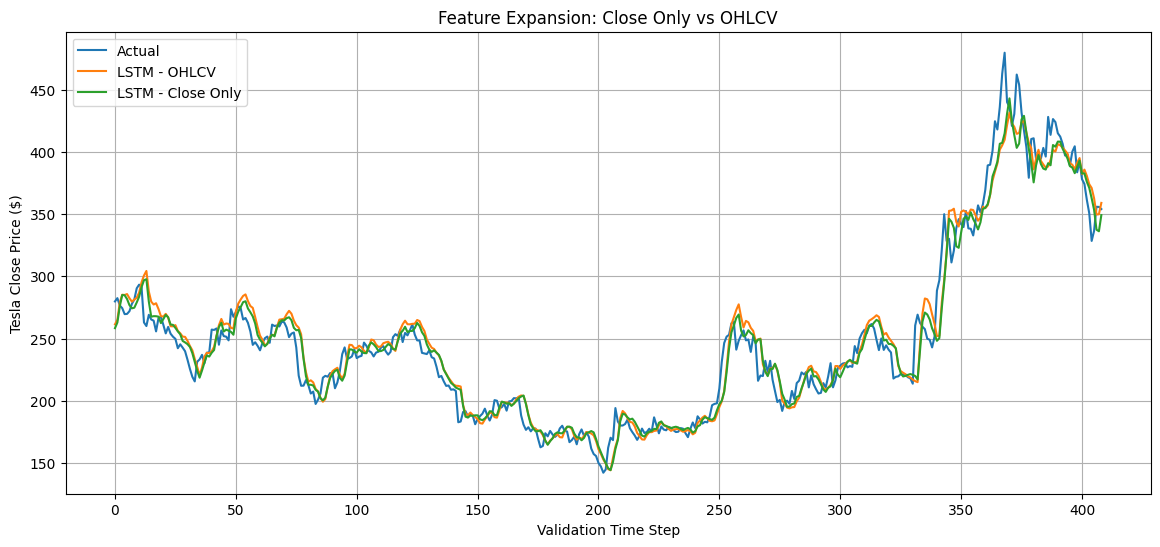

In [83]:
plt.figure(figsize=(14, 6))

plt.plot(
    val_actual_multi,
    label="Actual"
)

plt.plot(
    val_predictions_multi,
    label="LSTM - OHLCV"
)

plt.plot(
    val_predictions,
    label="LSTM - Close Only"
)

plt.xlabel("Validation Time Step")
plt.ylabel("Tesla Close Price ($)")
plt.title("Feature Expansion: Close Only vs OHLCV")
plt.legend()
plt.grid(True)
plt.show()

# Experiment 3 — Hidden Size

In [84]:
model_128 = TeslaLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

criterion_128 = nn.MSELoss()

optimizer_128 = torch.optim.Adam(
    model_128.parameters(),
    lr=1e-3
)

print(model_128)

print(
    "\nTrainable parameters:",
    sum(p.numel() for p in model_128.parameters()
        if p.requires_grad)
)

TeslaLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 199297


In [85]:
EPOCHS_128 = 50

history_128 = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_128 = float("inf")
best_model_state_128 = None

for epoch in range(EPOCHS_128):

    train_loss = train_one_epoch(
        model_128,
        train_loader,
        criterion_128,
        optimizer_128,
        device
    )

    val_loss = validate_one_epoch(
        model_128,
        val_loader,
        criterion_128,
        device
    )

    history_128["train_loss"].append(train_loss)
    history_128["val_loss"].append(val_loss)

    if val_loss < best_val_loss_128:
        best_val_loss_128 = val_loss

        best_model_state_128 = {
            key: value.detach().cpu().clone()
            for key, value in model_128.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_128}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("\nBest validation loss:", best_val_loss_128)

Epoch [01/50] Train Loss: 0.204186 | Val Loss: 0.139196
Epoch [02/50] Train Loss: 0.015786 | Val Loss: 0.057536
Epoch [03/50] Train Loss: 0.011369 | Val Loss: 0.048025
Epoch [04/50] Train Loss: 0.011623 | Val Loss: 0.047660
Epoch [05/50] Train Loss: 0.010702 | Val Loss: 0.035630
Epoch [06/50] Train Loss: 0.008493 | Val Loss: 0.045539
Epoch [07/50] Train Loss: 0.008123 | Val Loss: 0.068484
Epoch [08/50] Train Loss: 0.009408 | Val Loss: 0.031886
Epoch [09/50] Train Loss: 0.008707 | Val Loss: 0.064823
Epoch [10/50] Train Loss: 0.009097 | Val Loss: 0.033041
Epoch [11/50] Train Loss: 0.007643 | Val Loss: 0.029654
Epoch [12/50] Train Loss: 0.006972 | Val Loss: 0.033735
Epoch [13/50] Train Loss: 0.007611 | Val Loss: 0.038619
Epoch [14/50] Train Loss: 0.006892 | Val Loss: 0.041312
Epoch [15/50] Train Loss: 0.008464 | Val Loss: 0.027630
Epoch [16/50] Train Loss: 0.006673 | Val Loss: 0.036925
Epoch [17/50] Train Loss: 0.008476 | Val Loss: 0.035185
Epoch [18/50] Train Loss: 0.006593 | Val Loss: 0

In [86]:
model_128.load_state_dict(best_model_state_128)

model_128.eval()

val_predictions_128 = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model_128(X_batch)

        val_predictions_128.extend(
            predictions.cpu().numpy()
        )

val_predictions_128 = inverse_scale(
    np.array(val_predictions_128)
)

val_actual_128 = inverse_scale(y_val)

mae_128 = mean_absolute_error(
    val_actual_128,
    val_predictions_128
)

mse_128 = mean_squared_error(
    val_actual_128,
    val_predictions_128
)

rmse_128 = np.sqrt(mse_128)

print("LSTM - 60 Days - Hidden 128")
print("-" * 35)
print(f"MAE  : ${mae_128:.4f}")
print(f"MSE  : {mse_128:.4f}")
print(f"RMSE : ${rmse_128:.4f}")

LSTM - 60 Days - Hidden 128
-----------------------------------
MAE  : $10.0859
MSE  : 198.1184
RMSE : $14.0755


In [87]:
model_3layer = TeslaLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=3,
    dropout=0.2
).to(device)

criterion_3layer = nn.MSELoss()

optimizer_3layer = torch.optim.Adam(
    model_3layer.parameters(),
    lr=1e-3
)

print(model_3layer)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in model_3layer.parameters()
        if p.requires_grad
    )
)

TeslaLSTM(
  (lstm): LSTM(1, 128, num_layers=3, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 331393


In [88]:
EPOCHS_3LAYER = 50

history_3layer = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_3layer = float("inf")
best_model_state_3layer = None

for epoch in range(EPOCHS_3LAYER):

    train_loss = train_one_epoch(
        model_3layer,
        train_loader,
        criterion_3layer,
        optimizer_3layer,
        device
    )

    val_loss = validate_one_epoch(
        model_3layer,
        val_loader,
        criterion_3layer,
        device
    )

    history_3layer["train_loss"].append(train_loss)
    history_3layer["val_loss"].append(val_loss)

    if val_loss < best_val_loss_3layer:
        best_val_loss_3layer = val_loss

        best_model_state_3layer = {
            key: value.detach().cpu().clone()
            for key, value in model_3layer.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_3LAYER}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("\nBest validation loss:", best_val_loss_3layer)

Epoch [01/50] Train Loss: 0.219042 | Val Loss: 0.167407
Epoch [02/50] Train Loss: 0.021259 | Val Loss: 0.087379
Epoch [03/50] Train Loss: 0.014717 | Val Loss: 0.097294
Epoch [04/50] Train Loss: 0.012222 | Val Loss: 0.062516
Epoch [05/50] Train Loss: 0.011537 | Val Loss: 0.042039
Epoch [06/50] Train Loss: 0.010049 | Val Loss: 0.038066
Epoch [07/50] Train Loss: 0.009845 | Val Loss: 0.038653
Epoch [08/50] Train Loss: 0.010184 | Val Loss: 0.036076
Epoch [09/50] Train Loss: 0.009213 | Val Loss: 0.034909
Epoch [10/50] Train Loss: 0.012969 | Val Loss: 0.041899
Epoch [11/50] Train Loss: 0.010466 | Val Loss: 0.034993
Epoch [12/50] Train Loss: 0.008829 | Val Loss: 0.035489
Epoch [13/50] Train Loss: 0.007832 | Val Loss: 0.035499
Epoch [14/50] Train Loss: 0.009701 | Val Loss: 0.038933
Epoch [15/50] Train Loss: 0.007714 | Val Loss: 0.036112
Epoch [16/50] Train Loss: 0.008017 | Val Loss: 0.036228
Epoch [17/50] Train Loss: 0.007591 | Val Loss: 0.030982
Epoch [18/50] Train Loss: 0.007572 | Val Loss: 0

In [89]:
model_3layer.load_state_dict(best_model_state_3layer)
model_3layer.eval()

val_predictions_3layer = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model_3layer(X_batch)

        val_predictions_3layer.extend(
            predictions.cpu().numpy()
        )

val_predictions_3layer = inverse_scale(
    np.array(val_predictions_3layer)
)

val_actual_3layer = inverse_scale(y_val)

print("Predictions shape:", val_predictions_3layer.shape)

Predictions shape: (409,)


In [90]:
mae_3layer = mean_absolute_error(
    val_actual_3layer,
    val_predictions_3layer
)

mse_3layer = mean_squared_error(
    val_actual_3layer,
    val_predictions_3layer
)

rmse_3layer = np.sqrt(mse_3layer)

print("LSTM - 60 Days - Hidden 128 - 3 Layers")
print("-" * 45)
print(f"MAE  : ${mae_3layer:.4f}")
print(f"MSE  : {mse_3layer:.4f}")
print(f"RMSE : ${rmse_3layer:.4f}")

LSTM - 60 Days - Hidden 128 - 3 Layers
---------------------------------------------
MAE  : $10.4984
MSE  : 219.6399
RMSE : $14.8203


In [91]:
layer_comparison = pd.DataFrame({
    "Model": [
        "LSTM - 2 Layers",
        "LSTM - 3 Layers"
    ],
    "Hidden_Size": [128, 128],
    "Layers": [2, 3],
    "MAE": [
        mae_128,
        mae_3layer
    ],
    "MSE": [
        mse_128,
        mse_3layer
    ],
    "RMSE": [
        rmse_128,
        rmse_3layer
    ]
})

display(layer_comparison)

,Model,Hidden_Size,Layers,MAE,MSE,RMSE
0,LSTM - 2 Layers,128,2,10.085942,198.118449,14.075456
1,LSTM - 3 Layers,128,3,10.498357,219.639898,14.820253


# Experiment #5 — Dropout

In [92]:
model_dropout = TeslaLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.4
).to(device)

criterion_dropout = nn.MSELoss()

optimizer_dropout = torch.optim.Adam(
    model_dropout.parameters(),
    lr=1e-3
)

print(model_dropout)

TeslaLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.4)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [93]:
EPOCHS_DROPOUT = 50

history_dropout = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_dropout = float("inf")
best_model_state_dropout = None

for epoch in range(EPOCHS_DROPOUT):

    train_loss = train_one_epoch(
        model_dropout,
        train_loader,
        criterion_dropout,
        optimizer_dropout,
        device
    )

    val_loss = validate_one_epoch(
        model_dropout,
        val_loader,
        criterion_dropout,
        device
    )

    history_dropout["train_loss"].append(train_loss)
    history_dropout["val_loss"].append(val_loss)

    if val_loss < best_val_loss_dropout:
        best_val_loss_dropout = val_loss

        best_model_state_dropout = {
            key: value.detach().cpu().clone()
            for key, value in model_dropout.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_DROPOUT}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("\nBest validation loss:", best_val_loss_dropout)

Epoch [01/50] Train Loss: 0.214523 | Val Loss: 0.127443
Epoch [02/50] Train Loss: 0.016070 | Val Loss: 0.070889
Epoch [03/50] Train Loss: 0.012779 | Val Loss: 0.064110
Epoch [04/50] Train Loss: 0.010980 | Val Loss: 0.038026
Epoch [05/50] Train Loss: 0.009882 | Val Loss: 0.060624
Epoch [06/50] Train Loss: 0.010006 | Val Loss: 0.038490
Epoch [07/50] Train Loss: 0.009135 | Val Loss: 0.042154
Epoch [08/50] Train Loss: 0.009851 | Val Loss: 0.038394
Epoch [09/50] Train Loss: 0.008576 | Val Loss: 0.035265
Epoch [10/50] Train Loss: 0.008343 | Val Loss: 0.037889
Epoch [11/50] Train Loss: 0.008534 | Val Loss: 0.035378
Epoch [12/50] Train Loss: 0.008280 | Val Loss: 0.039618
Epoch [13/50] Train Loss: 0.007981 | Val Loss: 0.032485
Epoch [14/50] Train Loss: 0.007369 | Val Loss: 0.031957
Epoch [15/50] Train Loss: 0.008560 | Val Loss: 0.037758
Epoch [16/50] Train Loss: 0.007672 | Val Loss: 0.036710
Epoch [17/50] Train Loss: 0.007439 | Val Loss: 0.043685
Epoch [18/50] Train Loss: 0.007803 | Val Loss: 0

In [94]:
model_dropout.load_state_dict(
    best_model_state_dropout
)

model_dropout.eval()

val_predictions_dropout = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model_dropout(X_batch)

        val_predictions_dropout.extend(
            predictions.cpu().numpy()
        )

val_predictions_dropout = inverse_scale(
    np.array(val_predictions_dropout)
)

val_actual_dropout = inverse_scale(y_val)

print(
    "Predictions shape:",
    val_predictions_dropout.shape
)

Predictions shape: (409,)


In [95]:
mae_dropout = mean_absolute_error(
    val_actual_dropout,
    val_predictions_dropout
)

mse_dropout = mean_squared_error(
    val_actual_dropout,
    val_predictions_dropout
)

rmse_dropout = np.sqrt(mse_dropout)

print("LSTM - 60 Days - Hidden 128 - Dropout 0.4")
print("-" * 50)
print(f"MAE  : ${mae_dropout:.4f}")
print(f"MSE  : {mse_dropout:.4f}")
print(f"RMSE : ${rmse_dropout:.4f}")

LSTM - 60 Days - Hidden 128 - Dropout 0.4
--------------------------------------------------
MAE  : $10.4423
MSE  : 227.2962
RMSE : $15.0763


# Experiment 6 — Learning Rate

In [96]:
model_lr = TeslaLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

criterion_lr = nn.MSELoss()

optimizer_lr = torch.optim.Adam(
    model_lr.parameters(),
    lr=5e-4
)

print("Learning rate:", 5e-4)

Learning rate: 0.0005


In [97]:
EPOCHS_LR = 50

history_lr = {
    "train_loss": [],
    "val_loss": []
}

best_val_loss_lr = float("inf")
best_model_state_lr = None

for epoch in range(EPOCHS_LR):

    train_loss = train_one_epoch(
        model_lr,
        train_loader,
        criterion_lr,
        optimizer_lr,
        device
    )

    val_loss = validate_one_epoch(
        model_lr,
        val_loader,
        criterion_lr,
        device
    )

    history_lr["train_loss"].append(train_loss)
    history_lr["val_loss"].append(val_loss)

    if val_loss < best_val_loss_lr:
        best_val_loss_lr = val_loss

        best_model_state_lr = {
            key: value.detach().cpu().clone()
            for key, value in model_lr.state_dict().items()
        }

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_LR}] "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

print("\nBest validation loss:", best_val_loss_lr)

Epoch [01/50] Train Loss: 0.322046 | Val Loss: 0.154534
Epoch [02/50] Train Loss: 0.020581 | Val Loss: 0.095447
Epoch [03/50] Train Loss: 0.014631 | Val Loss: 0.091522
Epoch [04/50] Train Loss: 0.013412 | Val Loss: 0.048159
Epoch [05/50] Train Loss: 0.010830 | Val Loss: 0.064595
Epoch [06/50] Train Loss: 0.010970 | Val Loss: 0.040220
Epoch [07/50] Train Loss: 0.010352 | Val Loss: 0.040743
Epoch [08/50] Train Loss: 0.009471 | Val Loss: 0.050079
Epoch [09/50] Train Loss: 0.008530 | Val Loss: 0.044885
Epoch [10/50] Train Loss: 0.009051 | Val Loss: 0.040734
Epoch [11/50] Train Loss: 0.008504 | Val Loss: 0.039724
Epoch [12/50] Train Loss: 0.008594 | Val Loss: 0.037679
Epoch [13/50] Train Loss: 0.008016 | Val Loss: 0.040290
Epoch [14/50] Train Loss: 0.007969 | Val Loss: 0.033438
Epoch [15/50] Train Loss: 0.008314 | Val Loss: 0.034310
Epoch [16/50] Train Loss: 0.007515 | Val Loss: 0.036542
Epoch [17/50] Train Loss: 0.007300 | Val Loss: 0.033656
Epoch [18/50] Train Loss: 0.007253 | Val Loss: 0

In [98]:
model_lr.load_state_dict(best_model_state_lr)
model_lr.eval()

val_predictions_lr = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model_lr(X_batch)

        val_predictions_lr.extend(
            predictions.cpu().numpy()
        )

val_predictions_lr = inverse_scale(
    np.array(val_predictions_lr)
)

val_actual_lr = inverse_scale(y_val)

print("Predictions shape:", val_predictions_lr.shape)

Predictions shape: (409,)


In [99]:
mae_lr = mean_absolute_error(
    val_actual_lr,
    val_predictions_lr
)

mse_lr = mean_squared_error(
    val_actual_lr,
    val_predictions_lr
)

rmse_lr = np.sqrt(mse_lr)

print("LSTM - 60 Days - Hidden 128 - LR 0.0005")
print("-" * 50)
print(f"MAE  : ${mae_lr:.4f}")
print(f"MSE  : {mse_lr:.4f}")
print(f"RMSE : ${rmse_lr:.4f}")

LSTM - 60 Days - Hidden 128 - LR 0.0005
--------------------------------------------------
MAE  : $11.1454
MSE  : 236.7222
RMSE : $15.3858


# Final Model Selection

In [100]:
final_model = TeslaLSTM(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
).to(device)

final_criterion = nn.MSELoss()

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=1e-3
)

print(final_model)
print(
    "\nDevice:",
    next(final_model.parameters()).device
)

TeslaLSTM(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Device: cuda:0


In [101]:
total_params = sum(
    p.numel()
    for p in final_model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", total_params)

Trainable parameters: 199297


In [102]:
final_model.load_state_dict(best_model_state_128)

print("Final selected model restored.")
print("Best validation loss:", best_val_loss_128)

Final selected model restored.
Best validation loss: 0.021036261405732056


In [103]:
final_model.eval()

final_val_predictions = []

with torch.no_grad():
    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = final_model(X_batch)

        final_val_predictions.extend(
            predictions.cpu().numpy()
        )

final_val_predictions = inverse_scale(
    np.array(final_val_predictions)
)

final_val_actual = inverse_scale(y_val)

print("Predictions:", final_val_predictions.shape)
print("Actual     :", final_val_actual.shape)

Predictions: (409,)
Actual     : (409,)


In [104]:
final_val_mae = mean_absolute_error(
    final_val_actual,
    final_val_predictions
)

final_val_mse = mean_squared_error(
    final_val_actual,
    final_val_predictions
)

final_val_rmse = np.sqrt(final_val_mse)

print("FINAL LSTM — VALIDATION")
print("-" * 35)
print(f"MAE  : ${final_val_mae:.4f}")
print(f"MSE  : {final_val_mse:.4f}")
print(f"RMSE : ${final_val_rmse:.4f}")

print("\nNAIVE BASELINE")
print("-" * 35)
print(f"MAE  : ${val_mae:.4f}")
print(f"MSE  : {val_mse:.4f}")
print(f"RMSE : ${val_rmse:.4f}")

FINAL LSTM — VALIDATION
-----------------------------------
MAE  : $10.0859
MSE  : 198.1184
RMSE : $14.0755

NAIVE BASELINE
-----------------------------------
MAE  : $9.7032
MSE  : 186.4614
RMSE : $13.6551


In [105]:
validation_errors = (
    final_val_actual - final_val_predictions
)

absolute_errors = np.abs(validation_errors)

error_df = pd.DataFrame({
    "Actual": final_val_actual,
    "Predicted": final_val_predictions,
    "Error": validation_errors,
    "Absolute_Error": absolute_errors
})

display(error_df.head(10))

print("\nError statistics:")
display(error_df["Error"].describe())

,Actual,Predicted,Error,Absolute_Error
0,279.820007,260.197968,19.622040,19.622040
1,282.480011,263.993469,18.486542,18.486542
2,276.540009,279.703857,-3.163849,3.163849
3,274.429993,286.242310,-11.812317,11.812317
4,269.609985,282.722717,-13.112732,13.112732
5,269.790009,280.578705,-10.788696,10.788696
6,271.989990,276.492188,-4.502197,4.502197
7,277.899994,275.499756,2.400238,2.400238
8,281.380005,276.778748,4.601257,4.601257
9,290.380005,281.538361,8.841644,8.841644



Error statistics:


count    409.000000
mean      -0.660909
std       14.077150
min      -38.383743
25%       -8.820709
50%       -1.736145
75%        5.370239
max       57.913513
Name: Error, dtype: float64

In [106]:
largest_errors = (
    error_df
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

display(largest_errors)

,Actual,Predicted,Error,Absolute_Error
368,479.859985,421.946472,57.913513,57.913513
367,463.019989,407.920471,55.099518,55.099518
332,269.190002,216.715149,52.474854,52.474854
373,462.279999,410.021912,52.258087,52.258087
343,350.000000,299.535980,50.464020,50.464020
341,296.910004,253.766190,43.143814,43.143814
331,260.480011,219.892105,40.587906,40.587906
340,288.529999,249.375702,39.154297,39.154297
364,424.769989,386.167786,38.602203,38.602203
252,246.389999,207.813919,38.576080,38.576080


In [107]:
final_model.eval()

test_predictions = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        predictions = final_model(X_batch)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

test_predictions = inverse_scale(
    np.array(test_predictions)
)

test_actual = inverse_scale(y_test)

print("Predictions shape:", test_predictions.shape)
print("Actual shape     :", test_actual.shape)

Predictions shape: (410,)
Actual shape     : (410,)


In [108]:
final_test_mae = mean_absolute_error(
    test_actual,
    test_predictions
)

final_test_mse = mean_squared_error(
    test_actual,
    test_predictions
)

final_test_rmse = np.sqrt(final_test_mse)

print("FINAL LSTM — TEST")
print("-" * 35)
print(f"MAE  : ${final_test_mae:.4f}")
print(f"MSE  : {final_test_mse:.4f}")
print(f"RMSE : ${final_test_rmse:.4f}")

FINAL LSTM — TEST
-----------------------------------
MAE  : $14.4878
MSE  : 342.0373
RMSE : $18.4942


In [109]:
test_naive_predictions = test_df["Close"].values

test_naive_mae = mean_absolute_error(
    test_actual,
    test_naive_predictions
)

test_naive_mse = mean_squared_error(
    test_actual,
    test_naive_predictions
)

test_naive_rmse = np.sqrt(test_naive_mse)

print("NAIVE BASELINE — TEST")
print("-" * 35)
print(f"MAE  : ${test_naive_mae:.4f}")
print(f"MSE  : {test_naive_mse:.4f}")
print(f"RMSE : ${test_naive_rmse:.4f}")

NAIVE BASELINE — TEST
-----------------------------------
MAE  : $9.1940
MSE  : 145.9693
RMSE : $12.0818


In [110]:
final_test_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Final LSTM"
    ],
    "MAE": [
        test_naive_mae,
        final_test_mae
    ],
    "MSE": [
        test_naive_mse,
        final_test_mse
    ],
    "RMSE": [
        test_naive_rmse,
        final_test_rmse
    ]
})

display(final_test_results)

,Model,MAE,MSE,RMSE
0,Naive Baseline,9.194025,145.969336,12.081777
1,Final LSTM,14.487786,342.037255,18.494249


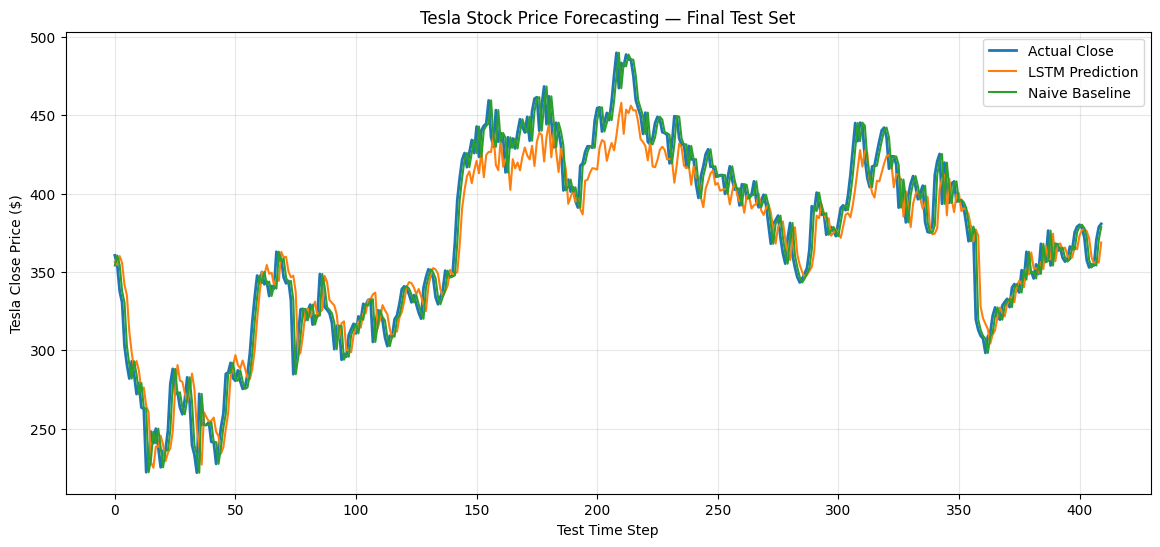

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test_actual,
    label="Actual Close",
    linewidth=2
)

plt.plot(
    test_predictions,
    label="LSTM Prediction",
    linewidth=1.5
)

plt.plot(
    test_naive_predictions,
    label="Naive Baseline",
    linewidth=1.5
)

plt.title("Tesla Stock Price Forecasting — Final Test Set")
plt.xlabel("Test Time Step")
plt.ylabel("Tesla Close Price ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

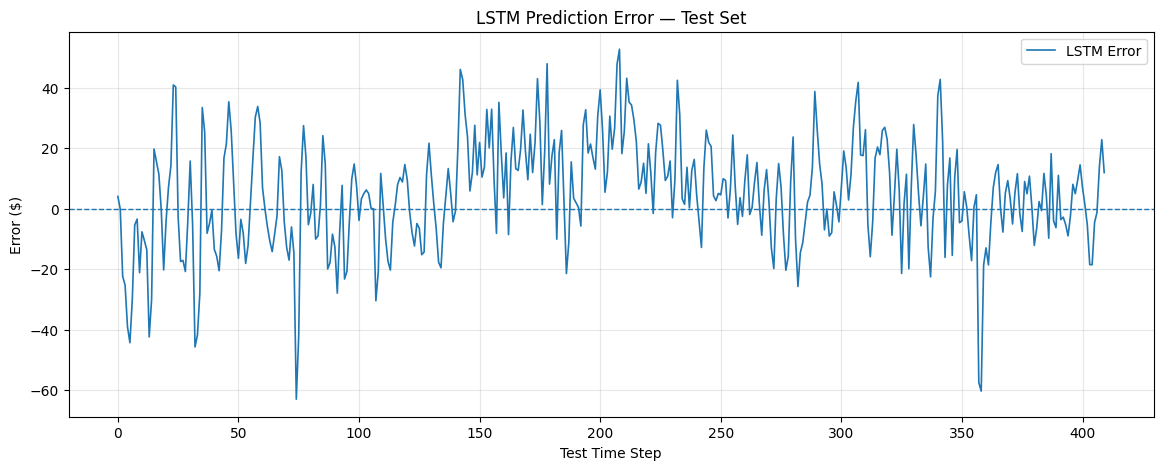

In [112]:
test_errors = test_actual - test_predictions
test_naive_errors = test_actual - test_naive_predictions

plt.figure(figsize=(14, 5))

plt.plot(
    test_errors,
    label="LSTM Error",
    linewidth=1.2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("LSTM Prediction Error — Test Set")
plt.xlabel("Test Time Step")
plt.ylabel("Error ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Test Error Statistics:


count    410.000000
mean       4.731408
std       17.900631
min      -62.921326
25%       -5.972801
50%        5.025620
75%       16.517944
max       52.673248
dtype: float64

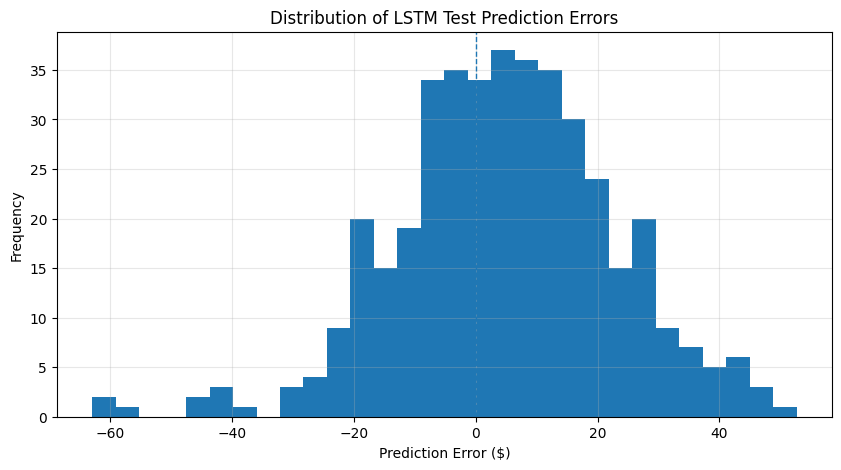

In [113]:
import pandas as pd

test_error_stats = pd.Series(test_errors).describe()

print("Test Error Statistics:")
display(test_error_stats)

plt.figure(figsize=(10, 5))

plt.hist(
    test_errors,
    bins=30
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Distribution of LSTM Test Prediction Errors")
plt.xlabel("Prediction Error ($)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()